# 03 · BAO con DESI DR2

Notebook consolidado: 9 escenarios cosmológicos sobre **DESI BAO DR2** (Gaussian likelihood), del más simple (wCDM 2D) al más complejo (5D con priors completos de Planck+SNe+BAO).

Todos los escenarios usan la misma receta validada:
- Sampling: `build_chi2_dataset` con rodajas + nube random (caché en `outputs/datasets/`).
- Entrenamiento: `train_xgb(log_target=True, ...)` con caché de modelos.
- Hiperparámetros XGBoost: `n_estimators=3000, learning_rate=0.03, max_depth=10`, `tree_method='hist'`, early stopping con `min_delta=1e-4` (auto en log-target).
- Contornos: `res=200, sigma=2.0, theory_threshold=20` con zoom manual al best-fit.
- SHAP: directo sobre `info["X_val"]`. Los valores SHAP están en escala log10(χ²) — contribución de 0.5 ≈ factor ×3 en χ².

### Convención de archivos

Cada sección §3.X usa `SECTION = "3_X"` como prefijo:
- Dataset:      `outputs/datasets/{SECTION}_dataset.csv`
- Modelo:       `outputs/models/{SECTION}_model.ubj` (+ `.info.pkl`)
- Figuras:      `outputs/figures/03_BAO/{SECTION}_*.png`

## Índice

| §   | Escenario                                       | Dim | Parámetros libres                       | Notas |
|-----|-------------------------------------------------|-----|-----------------------------------------|-------|
| [3.1](#3-1) | **wCDM**                                | 2   | Ω_m, w                                  | Baseline; wₐ=0; H₀, r_d Planck |
| [3.2](#3-2) | **wCDM con H₀ libre**                   | 3   | Ω_m, w, H₀                              | Extensión natural del 3.1; r_d=Planck |
| [3.3](#3-3) | **w₀wₐCDM (DESI completo)**             | 3   | Ω_m, w₀, wₐ                             | Resultado principal: LCDM excluido a >4σ |
| [3.4](#3-4) | **w₀wₐCDM (z < 2)**                     | 3   | Ω_m, w₀, wₐ                             | Sin Lyman-α (z=2.33); contornos más anchos |
| [3.5](#3-5) | **w₀wₐCDM + r_d=Planck**                | 4   | Ω_m, w₀, wₐ, H₀                         | r_d fijado, H₀ libre |
| [3.6](#3-6) | **w₀wₐCDM con H₀·r_d**                  | 4   | Ω_m, w₀, wₐ, **H₀·r_d**                 | BAO sólo depende del PRODUCTO H₀·r_d |
| [3.7](#3-7) | **Degeneración H₀–r_d (SHAP)**          | 5   | Ω_m, w₀, wₐ, H₀, r_d (sin priors)       | Justifica el truco del 3.6 vía SHAP |
| [3.8](#3-8) | **w₀wₐCDM + 3 Planck priors**           | 5   | Ω_m, w₀, wₐ, H₀, r_d (priors en 3)      | Priors gauss en Ω_m, H₀, r_d |
| [3.9](#3-9) | **w₀wₐCDM + 5 Planck priors**           | 5   | Ω_m, w₀, wₐ, H₀, r_d (priors en 5)      | Priors en TODOS — Planck+SNe+BAO 2018 |

> **Cómo usar:** ejecuta primero la celda de [setup](#setup). Después puedes ir a cualquier escenario y correr sus celdas en orden — cada sección redefine `SECTION`, `FEATURES`, `REF`, `chi2_fn`, etc.
>
> **Caché:** modelos en `outputs/models/{SECTION}_model.ubj`. Re-ejecutar el training es instantáneo a menos que `FORCE_RETRAIN=True`.

## <a id="setup"></a>Setup (ejecutar primero)

In [77]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd
import scipy.optimize as opt
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from cosmoml.data import load_desi_bao
from cosmoml.theory.bao import chi2_bao
from cosmoml.priors import planck_prior_chi2, gaussian_prior
from cosmoml.sampling import build_chi2_dataset, load_or_build
from cosmoml.ml import (
    train_xgb, plot_contour_2d, plot_learning_curve,
    shap_summary, shap_waterfall, shap_dependence_all,
    use_paper_style,
)
from cosmoml.config import OUTPUTS_DIR, PLANCK_H0, PLANCK_RD, PLANCK_OM

use_paper_style()

bao_full = load_desi_bao()
bao_z2   = load_desi_bao(z_max=2.0)
print(f"DESI BAO completo: {len(bao_full)} medidas en {len(bao_full.unique_z)} redshifts {bao_full.unique_z}")
print(f"DESI BAO z<2:      {len(bao_z2)} medidas en {len(bao_z2.unique_z)} redshifts {bao_z2.unique_z}")

NB_NAME = "03_BAO"
DATASETS_DIR = OUTPUTS_DIR / "datasets"
MODELS_DIR   = OUTPUTS_DIR / "models"
FIGURES_DIR  = OUTPUTS_DIR / "figures" / NB_NAME
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

FORCE_RETRAIN = False
print(f"\nDatasets:  {DATASETS_DIR}/{{SECTION}}_dataset.csv")
print(f"Modelos:   {MODELS_DIR}/{{SECTION}}_model.ubj  (FORCE_RETRAIN={FORCE_RETRAIN})")
print(f"Figuras:   {FIGURES_DIR}/{{SECTION}}_*.png")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
DESI BAO completo: 13 medidas en 7 redshifts [0.295 0.51  0.706 0.934 1.321 1.484 2.33 ]
DESI BAO z<2:      11 medidas en 6 redshifts [0.295 0.51  0.706 0.934 1.321 1.484]

Datasets:  /home/aleja/PhysicsML/CosmoML/outputs/datasets/{SECTION}_dataset.csv
Modelos:   /home/aleja/PhysicsML/CosmoML/outputs/models/{SECTION}_model.ubj  (FORCE_RETRAIN=False)
Figuras:   /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/{SECTION}_*.png


## <a id="3-1"></a>3.1 wCDM — 2D (Ω_m, w)

**Modelo:** `FlatwCDM` con wₐ=0 fijo. H₀ y r_d fijados al fiducial Planck.
**Datos:** DESI BAO DR2 (todos los redshifts).
**Por qué:** baseline más simple para visualizar la degeneración Ω_m–w sin la complicación de wₐ.

Refactor de `legacy/root/BAO_wCDM_*`.

In [2]:
SECTION = "3_1"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w"]
REF = dict(Om=0.315, w=-1.0)

def chi2_fn(Om, w):
    return chi2_bao(bao_full, Om=Om, w0=w, wa=0.0, H0=PLANCK_H0, rd=PLANCK_RD)

print(f"χ²(ΛCDM Planck) = {chi2_fn(**REF):.3f}")

χ²(ΛCDM Planck) = 30.681


In [3]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        random_box=dict(Om=(0.1, 0.6), w=(-3.0, 0.0)),
        n_random=500_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min χ² = {df['chi2'].min():.3f}")

Cargando dataset existente: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_1_dataset.csv
min χ² = 9.208


In [4]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  descartando 49 filas con chi² >= 90000.0 (fallos integración)
  target en Shifted-Log10: rango [0.000, 4.954]


/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [00:40:53] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


  entrenamiento: 11.99s | R²=0.99981 | best_iter=385/3000  (early stop, ahorro ~87%)
  modelo cacheado: 3_1_model.ubj


  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_learning_curve.png


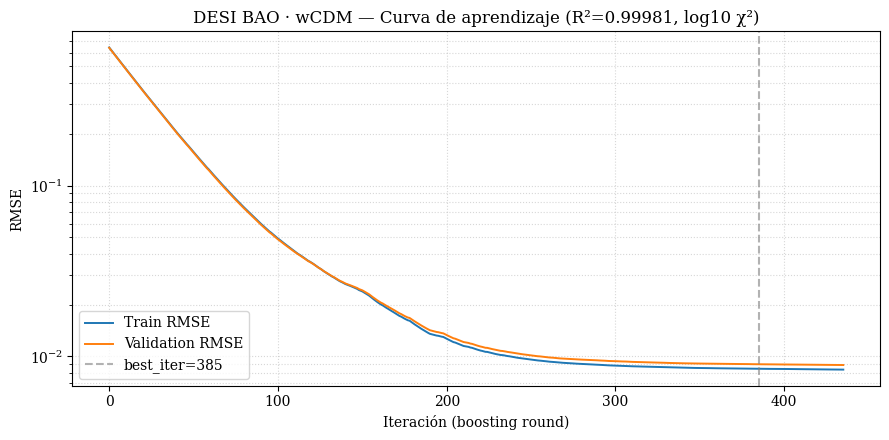

In [5]:
plot_learning_curve(
    info,
    title=f"DESI BAO · wCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w$ vs $\Omega_m$  ({}) ---
  calculando teoría (en paralelo)...


  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_Om_w.png


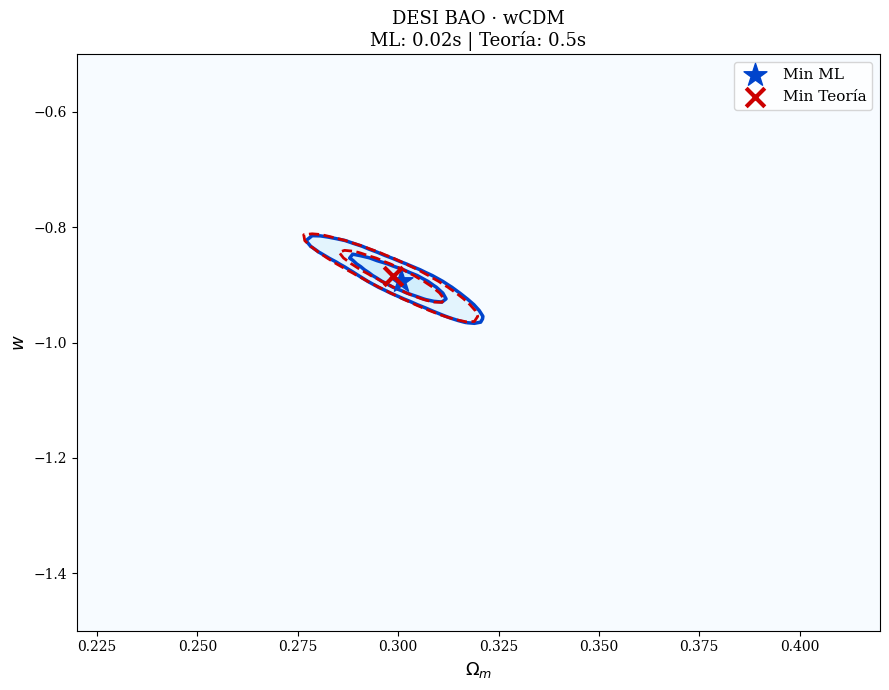

{'Z_ml': array([[5386.4062 , 5324.012  , 5214.85   , ...,  226.06525,  229.64468,
          231.71292],
        [5345.2583 , 5283.2197 , 5174.686  , ...,  225.31525,  228.95694,
          231.0613 ],
        [5271.9097 , 5210.4688 , 5103.0117 , ...,  224.06313,  227.82452,
          229.99678],
        ...,
        [ 491.54218,  495.92798,  504.13443, ..., 2433.0774 , 2448.0806 ,
         2456.6094 ],
        [ 526.3515 ,  531.10474,  539.91644, ..., 2478.3005 , 2492.1406 ,
         2500.0352 ],
        [ 546.871  ,  551.8427 ,  561.0104 , ..., 2504.4207 , 2517.537  ,
         2525.0334 ]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.020389318466186523,
 'time_th': 0.491591215

In [6]:
common = dict(res=100, sigma=2.0, theory_threshold=12)

plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w",
    x_range=(0.22, 0.42), y_range=(-1.5, -0.5),
    fixed={},
    theory_fn=chi2_fn,
    title=r"DESI BAO · wCDM",
    x_label=r"$\Omega_m$", y_label=r"$w$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_w.png",
    show=True, **common,
)

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_beeswarm.png


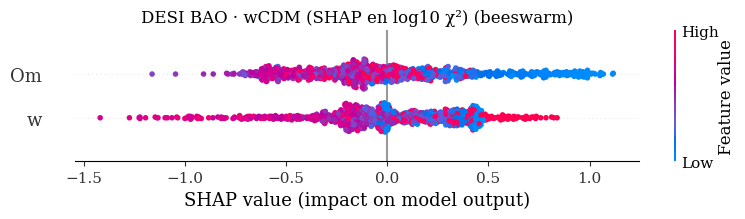

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_bar.png


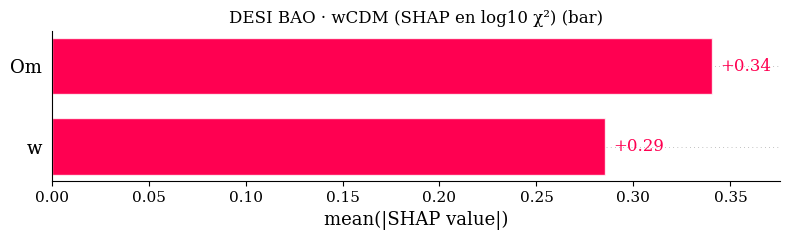

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_waterfall.png


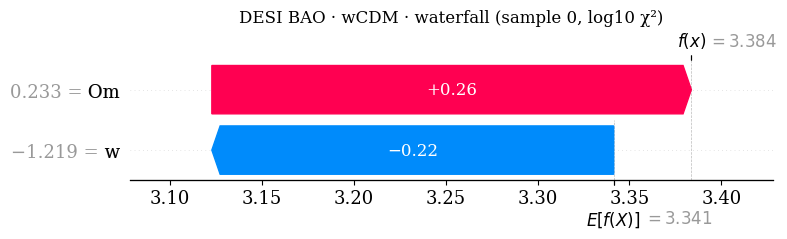

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_Om.png


<Figure size 640x480 with 0 Axes>

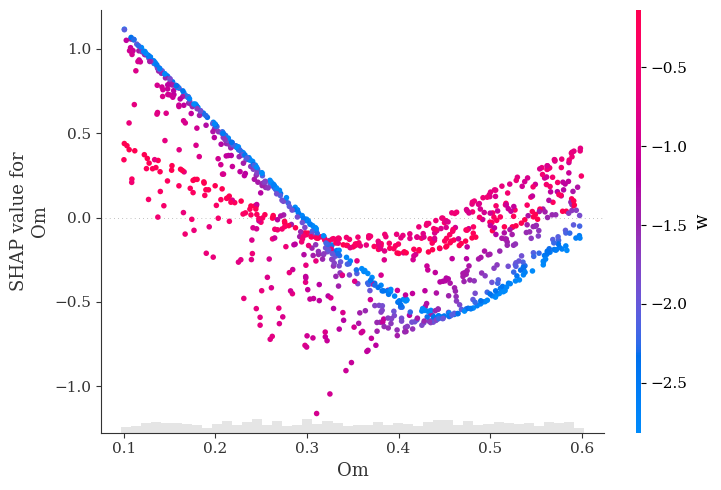

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_w.png


<Figure size 640x480 with 0 Axes>

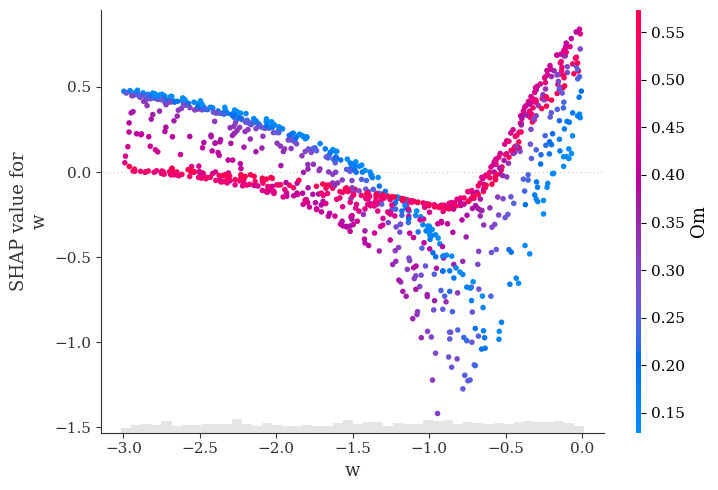

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_w.png')]

In [7]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DESI BAO · wCDM (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DESI BAO · wCDM · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-2"></a>3.2 wCDM con H₀ libre — 3D (Ω_m, w, H₀)

**Modelo:** `FlatwCDM` con wₐ=0 fijo. H₀ libre, r_d fijado al fiducial Planck.
**Datos:** DESI BAO DR2.
**Por qué:** versión intermedia entre §3.1 (wCDM 2D, H₀ fijo) y §3.5 (w₀wₐCDM 4D con H₀). Permite estudiar la degeneración H₀–w sin la complicación de wₐ. Como en §3.5, sin priors externos los datos BAO no fijan H₀ sólo (con r_d ya fijo) → contornos anchos en H₀.

Refactor de `legacy/root/BAO_wCDMH0_*`.

In [8]:
SECTION = "3_2"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w", "H0"]
REF = dict(Om=0.315, w=-1.0, H0=PLANCK_H0)

def chi2_fn(Om, w, H0):
    return chi2_bao(bao_full, Om=Om, w0=w, wa=0.0, H0=H0, rd=PLANCK_RD)

print(f"χ²(LCDM Planck) = {chi2_fn(**REF):.3f}")

χ²(LCDM Planck) = 30.681


In [9]:
def builder():
    N = 30_000
    pares = [('Om','w'), ('Om','H0'), ('w','H0')]
    rangos = dict(Om=(0.05, 0.6), w=(-2.5, 0.0), H0=(50, 90))
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=0,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min χ² = {df['chi2'].min():.3f}")

Cargando dataset existente: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_2_dataset.csv
min χ² = 9.536


In [10]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  descartando 532 filas con chi² >= 90000.0 (fallos integración)
  target en Shifted-Log10: rango [0.000, 4.954]
  entrenamiento: 19.71s | R²=0.99925 | best_iter=982/3000  (early stop, ahorro ~67%)
  modelo cacheado: 3_2_model.ubj


  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_learning_curve.png


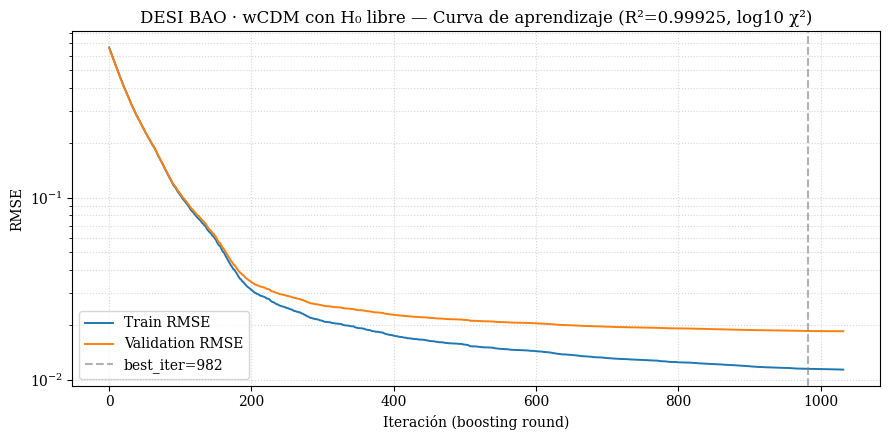

In [11]:
plot_learning_curve(
    info,
    title=f"DESI BAO · wCDM con H₀ libre — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w$ vs $\Omega_m$  ({'H0': 67.36}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_Om_w.png


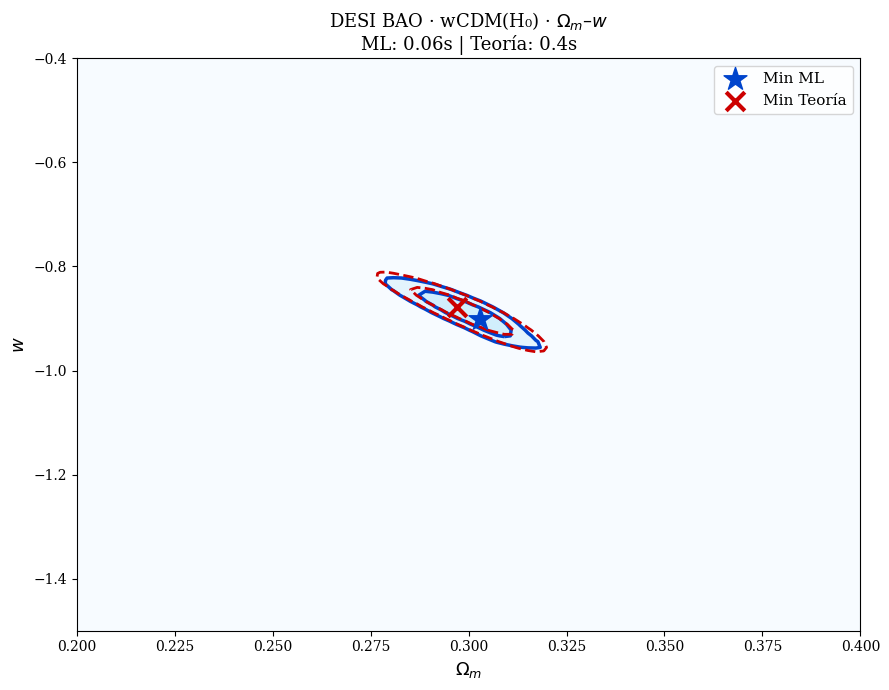

--- $H_0$ vs $\Omega_m$  ({'w': -1.0}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_Om_H0.png


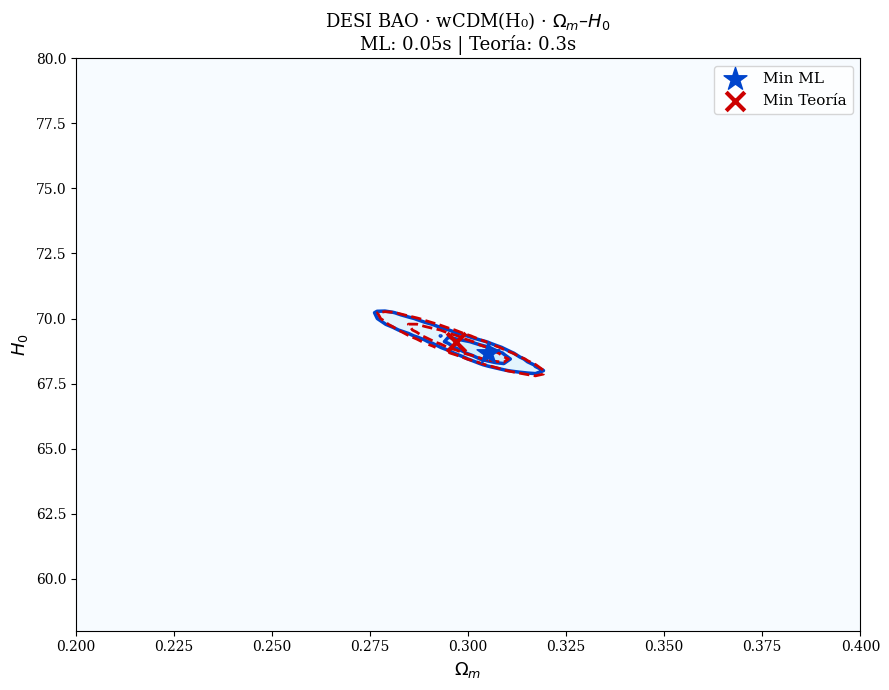

--- $H_0$ vs $w$  ({'Om': 0.315}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_w_H0.png


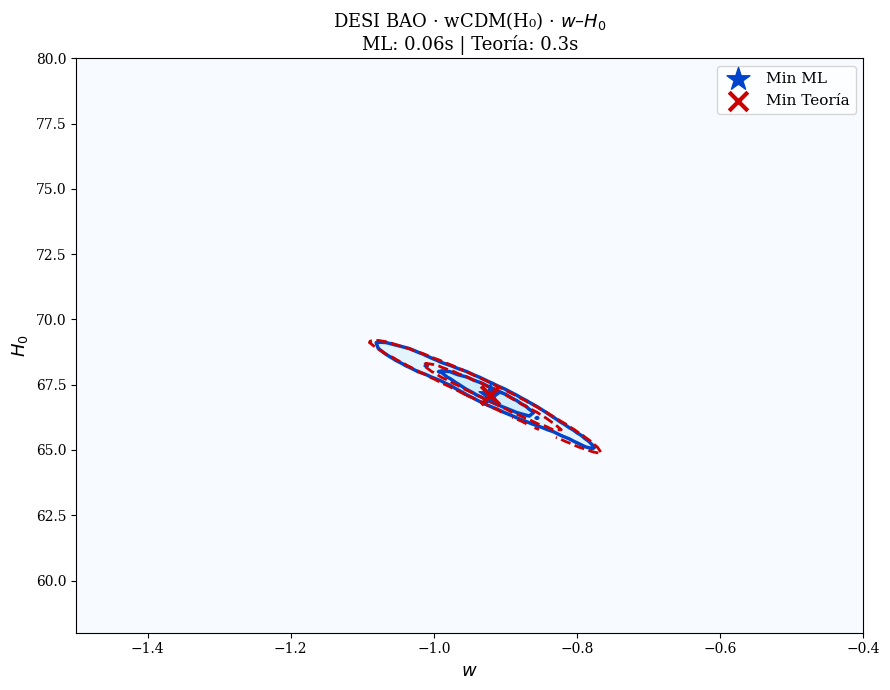

In [12]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(Om=(0.20, 0.40), w=(-1.5, -0.4), H0=(58, 80))
LABELS = dict(Om=r"$\Omega_m$", w=r"$w$", H0=r"$H_0$")

for x, y in [('Om','w'), ('Om','H0'), ('w','H0')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DESI BAO · wCDM(H₀) · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
    )

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_beeswarm.png


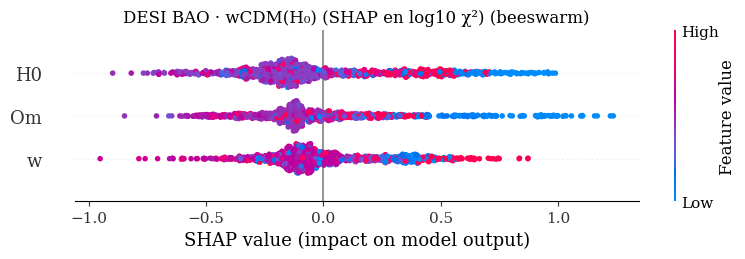

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_bar.png


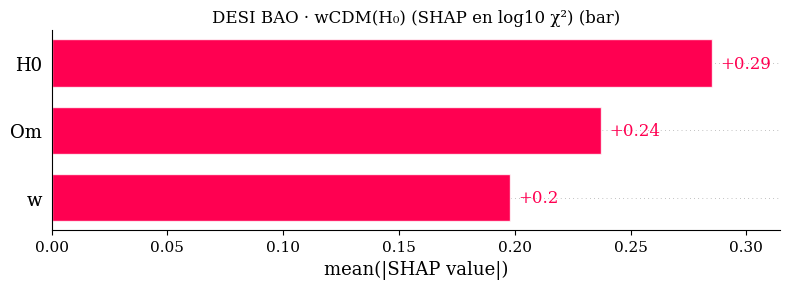

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_waterfall.png


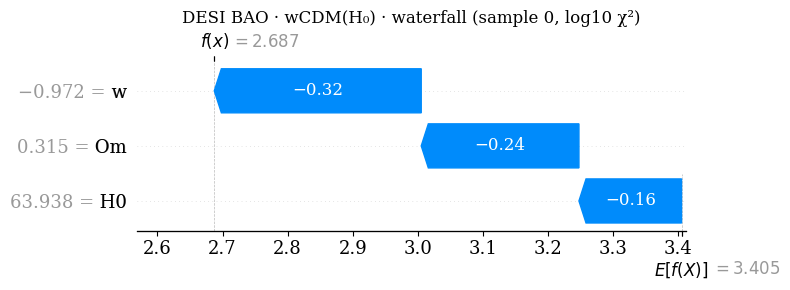

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_Om.png


<Figure size 640x480 with 0 Axes>

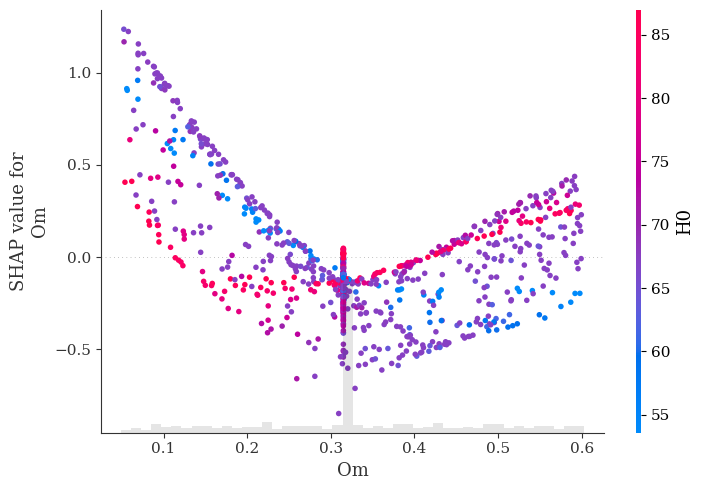

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_w.png


<Figure size 640x480 with 0 Axes>

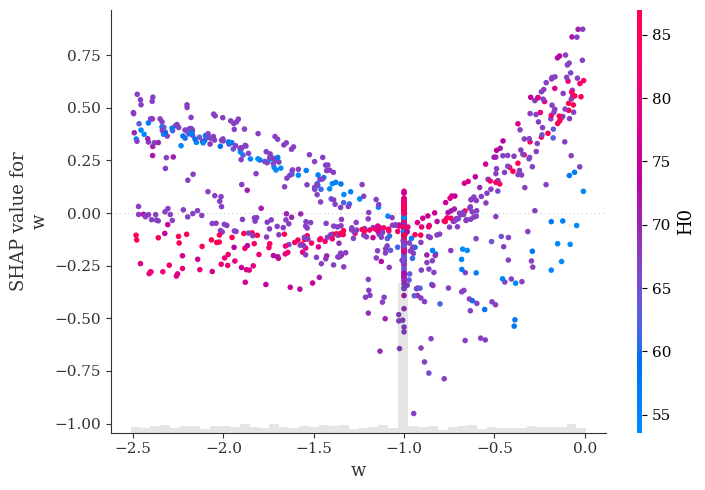

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_H0.png


<Figure size 640x480 with 0 Axes>

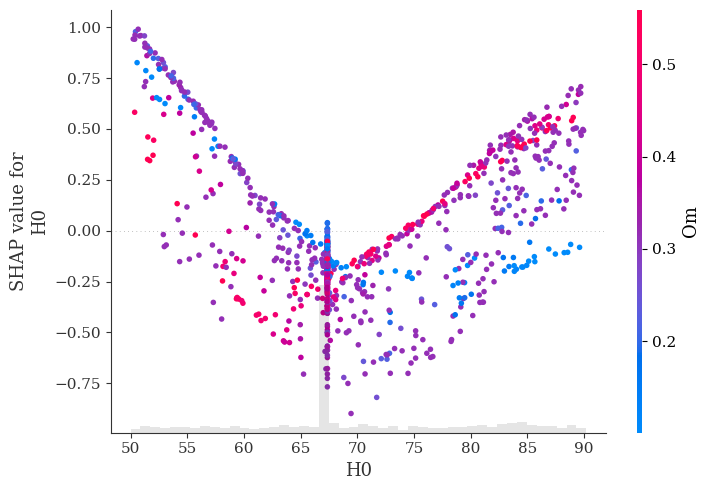

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_w.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_H0.png')]

In [13]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DESI BAO · wCDM(H₀) (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DESI BAO · wCDM(H₀) · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-3"></a>3.3 w₀wₐCDM con DESI completo — 3D

**Modelo:** `Flatw0waCDM` (CPL: w(z) = w₀ + wₐ·z/(1+z)). H₀ y r_d fijos al fiducial Planck.
**Datos:** DESI BAO DR2 (todos los redshifts, incluida la medida Lyman-α en z=2.33).
**Por qué:** **resultado principal del paper.** Con todas las medidas DESI, ΛCDM (w₀=-1, wₐ=0) queda excluido a más de 4σ — los contornos al 1σ y 2σ son muy estrechos y descartan el modelo cosmológico estándar.

Refactor de `legacy/BAOw0wa/BAO_w0waCDM_*`.

In [14]:
SECTION = "3_3"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]
REF = dict(Om=0.315, w0=-1.0, wa=0.0)

def chi2_fn(Om, w0, wa):
    return chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=PLANCK_H0, rd=PLANCK_RD)

print(f"χ²(ΛCDM Planck) = {chi2_fn(**REF):.3f}")

χ²(ΛCDM Planck) = 30.681


In [15]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(Om=0.315,        w0=(-2.5, 0.5), wa=(-3.5, 3.5), _n=100_000),
            dict(Om=(0.1, 0.6),   w0=(-2.5, 0.5), wa=0.0,         _n=100_000),
            dict(Om=(0.1, 0.6),   w0=-1.0,        wa=(-3.5, 3.5), _n=100_000),
        ],
        random_box=dict(Om=(0.1, 0.6), w0=(-3.0, 1.0), wa=(-4.0, 4.0)),
        n_random=300_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min χ² = {df['chi2'].min():.3f}")

Cargando dataset existente: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_3_dataset.csv
min χ² = 8.266


In [16]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  descartando 145 filas con chi² >= 90000.0 (fallos integración)
  target en Shifted-Log10: rango [0.000, 4.954]
  entrenamiento: 30.23s | R²=0.99932 | best_iter=1252/3000  (early stop, ahorro ~58%)
  modelo cacheado: 3_3_model.ubj


  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_learning_curve.png


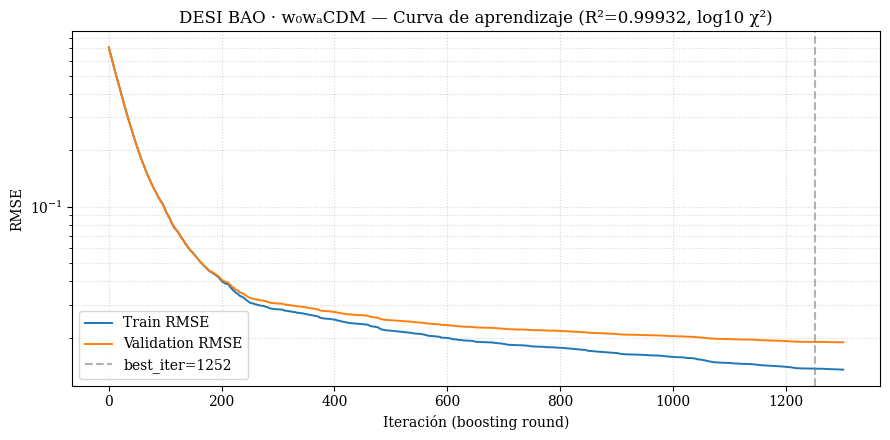

In [17]:
plot_learning_curve(
    info,
    title=f"DESI BAO · w₀wₐCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w_a$ vs $w_0$  ({'Om': 0.315}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_w0_wa.png


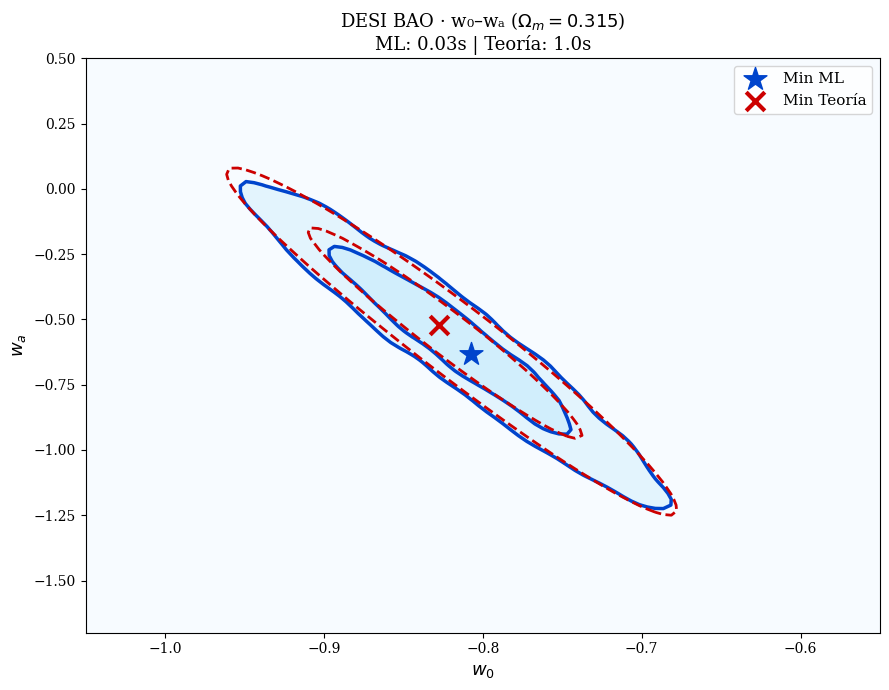

--- $w_0$ vs $\Omega_m$  ({'wa': 0.0}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_Om_w0.png


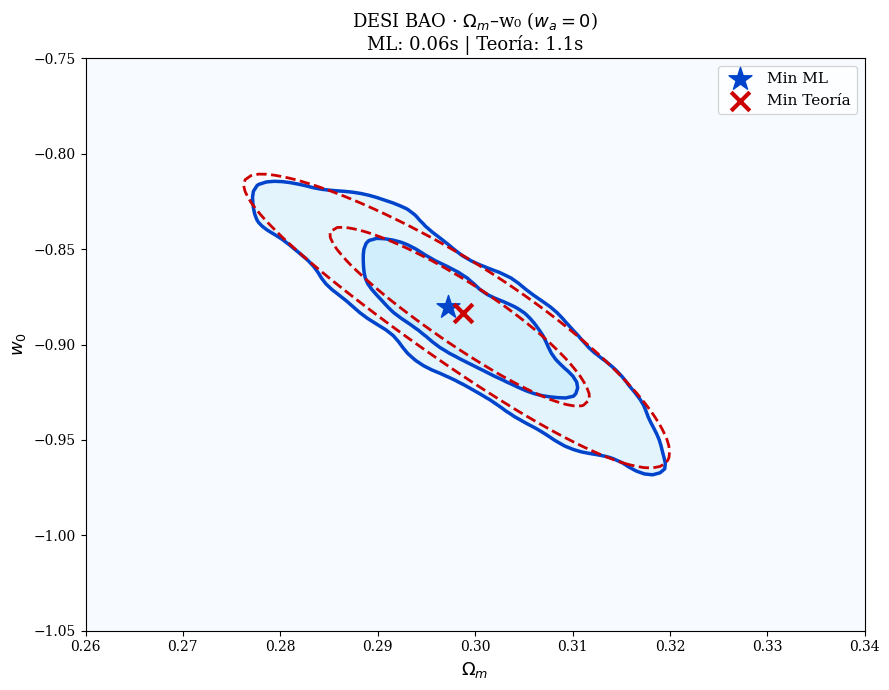

--- $w_a$ vs $\Omega_m$  ({'w0': -1.0}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_Om_wa.png


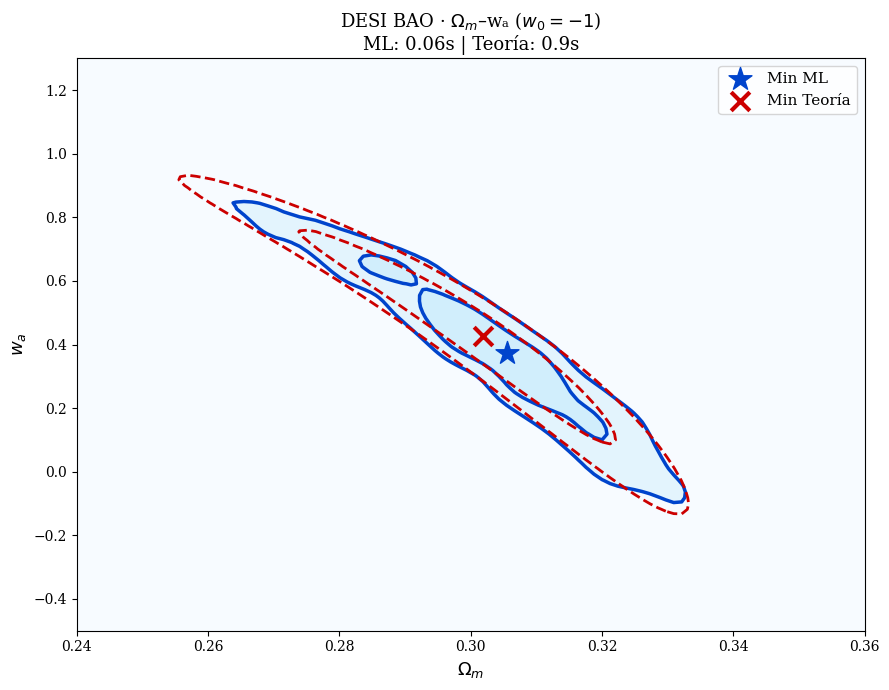

{'Z_ml': array([[1293.9105  , 1281.8165  , 1260.2449  , ...,   48.64552 ,
           50.414272,   51.41395 ],
        [1291.8665  , 1279.7549  , 1258.1138  , ...,   48.931473,
           50.75246 ,   51.782803],
        [1288.3518  , 1276.1716  , 1254.3175  , ...,   49.420036,
           51.329094,   52.411175],
        ...,
        [  93.12076 ,   93.95777 ,   95.41304 , ...,  919.2089  ,
          924.26135 ,  926.9261  ],
        [  99.21345 ,  100.058464,  101.53508 , ...,  942.0683  ,
          947.023   ,  949.62463 ],
        [ 102.62931 ,  103.4676  ,  104.940926, ...,  953.944   ,
          958.9066  ,  961.50885 ]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.0629551

In [18]:
# DESI completo es muy restrictivo (LCDM excluido a >4σ): zoom manual al best-fit.
common = dict(res=100, sigma=2.0, theory_threshold=12)

plot_contour_2d(
    model, features=FEATURES,
    x_param="w0", y_param="wa",
    x_range=(-1.05, -0.55), y_range=(-1.7, 0.5),
    fixed=dict(Om=REF["Om"]),
    theory_fn=chi2_fn,
    title=r"DESI BAO · w₀–wₐ ($\Omega_m=0.315$)",
    x_label=r"$w_0$", y_label=r"$w_a$",
    save_path=FIGURES_DIR / f"{SECTION}_w0_wa.png",
    show=True, **common,
)
plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w0",
    x_range=(0.26, 0.34), y_range=(-1.05, -0.75),
    fixed=dict(wa=0.0),
    theory_fn=chi2_fn,
    title=r"DESI BAO · $\Omega_m$–w₀ ($w_a=0$)",
    x_label=r"$\Omega_m$", y_label=r"$w_0$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_w0.png",
    show=True, **common,
)
plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="wa",
    x_range=(0.24, 0.36), y_range=(-0.5, 1.3),
    fixed=dict(w0=-1.0),
    theory_fn=chi2_fn,
    title=r"DESI BAO · $\Omega_m$–wₐ ($w_0=-1$)",
    x_label=r"$\Omega_m$", y_label=r"$w_a$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_wa.png",
    show=True, **common,
)

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_beeswarm.png


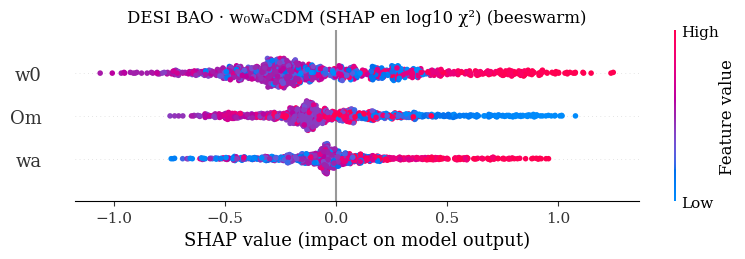

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_bar.png


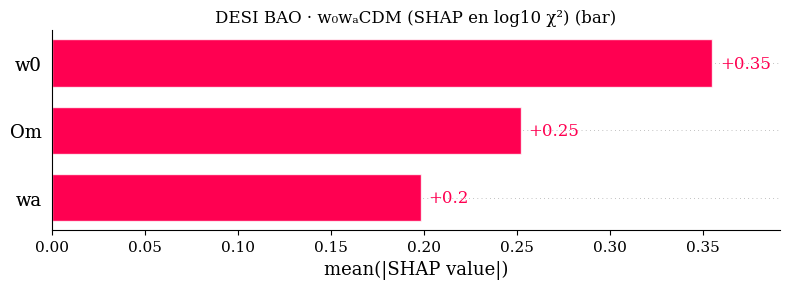

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_waterfall.png


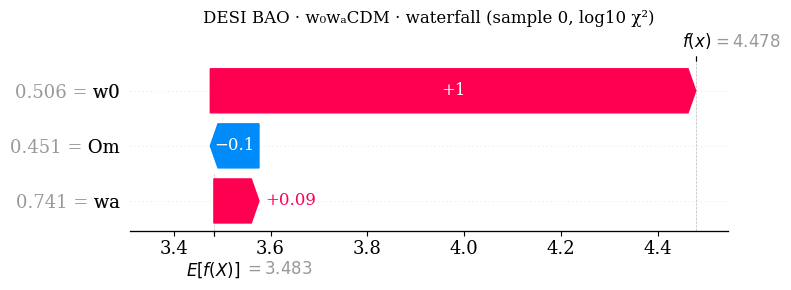

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_Om.png


<Figure size 640x480 with 0 Axes>

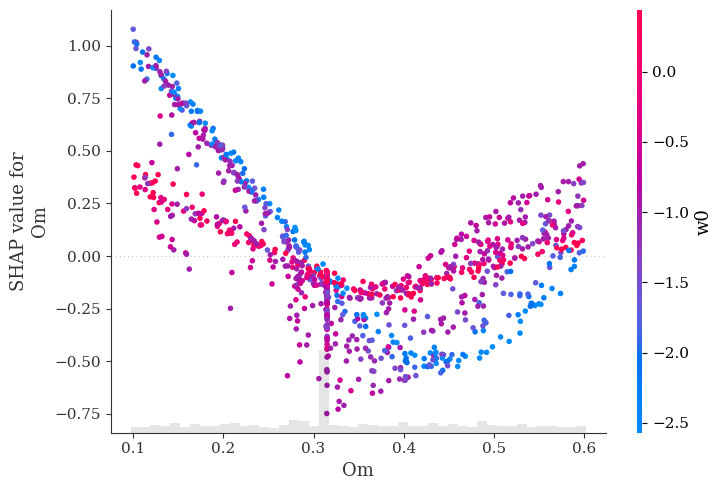

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_w0.png


<Figure size 640x480 with 0 Axes>

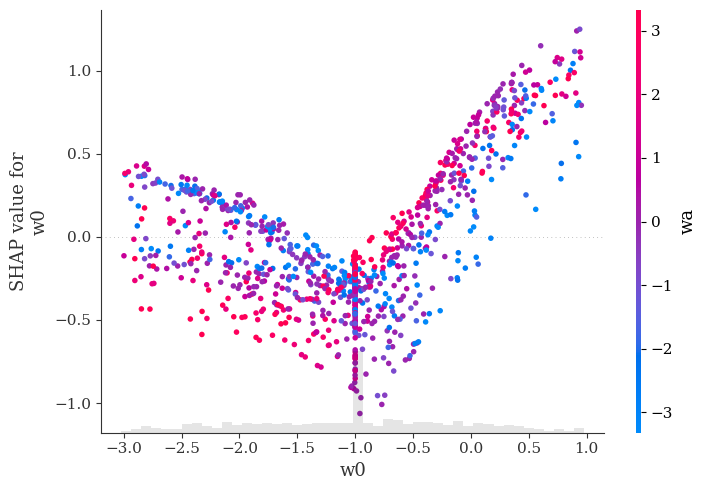

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_wa.png


<Figure size 640x480 with 0 Axes>

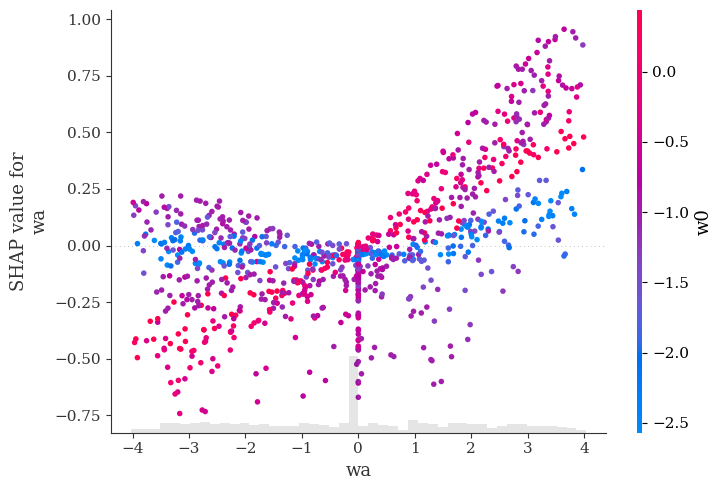

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_wa.png')]

In [19]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DESI BAO · w₀wₐCDM (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DESI BAO · w₀wₐCDM · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-4"></a>3.4 w₀wₐCDM (z < 2, sin Lyman-α) — 3D

**Modelo:** mismo que 3.3.
**Datos:** DESI BAO DR2 con corte **z < 2** — descarta la medida Lyman-α en z=2.33.
**Por qué:** la señal Lyman-α en z=2.33 es la que más empuja la tensión con ΛCDM. Al eliminarla los contornos se ensanchan considerablemente.

Refactor de `legacy/BAOw0wa/BAO_w0waCDM_z2_*`.

In [20]:
SECTION = "3_4"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]
REF = dict(Om=0.315, w0=-1.0, wa=0.0)

def chi2_fn(Om, w0, wa):
    return chi2_bao(bao_z2, Om=Om, w0=w0, wa=wa, H0=PLANCK_H0, rd=PLANCK_RD)

print(f"χ²(ΛCDM Planck, z<2) = {chi2_fn(**REF):.3f}")

χ²(ΛCDM Planck, z<2) = 30.522


In [21]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(Om=0.315,        w0=(-2.5, 0.5), wa=(-3.5, 3.5), _n=100_000),
            dict(Om=(0.1, 0.6),   w0=(-2.5, 0.5), wa=0.0,         _n=100_000),
            dict(Om=(0.1, 0.6),   w0=-1.0,        wa=(-3.5, 3.5), _n=100_000),
        ],
        random_box=dict(Om=(0.1, 0.6), w0=(-3.0, 1.0), wa=(-4.0, 4.0)),
        n_random=300_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min χ² = {df['chi2'].min():.3f}")

Cargando dataset existente: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_4_dataset.csv
min χ² = 7.112


In [22]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  descartando 1 filas con chi² >= 90000.0 (fallos integración)
  target en Shifted-Log10: rango [0.000, 4.951]
  entrenamiento: 30.21s | R²=0.99914 | best_iter=1256/3000  (early stop, ahorro ~58%)
  modelo cacheado: 3_4_model.ubj


  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_learning_curve.png


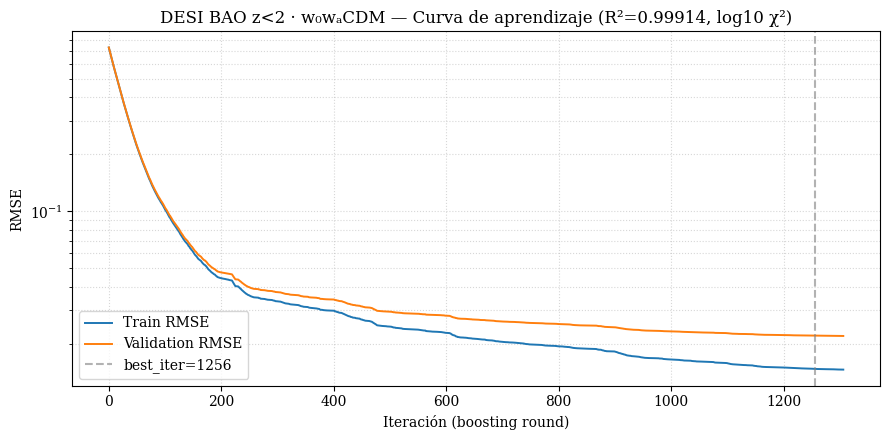

In [23]:
plot_learning_curve(
    info,
    title=f"DESI BAO z<2 · w₀wₐCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w_a$ vs $w_0$  ({'Om': 0.315}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_w0_wa.png


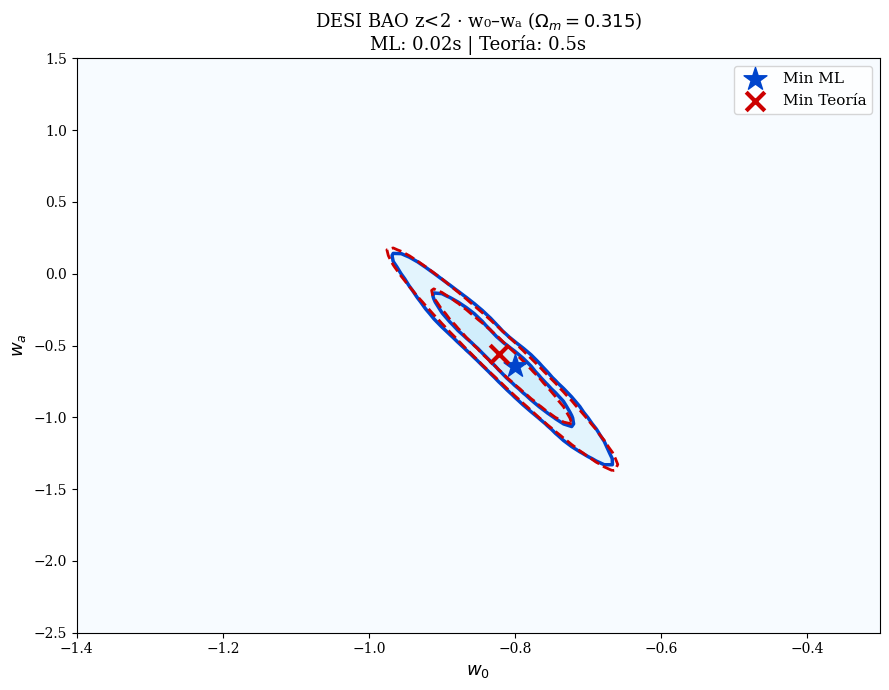

--- $w_0$ vs $\Omega_m$  ({'wa': 0.0}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_Om_w0.png


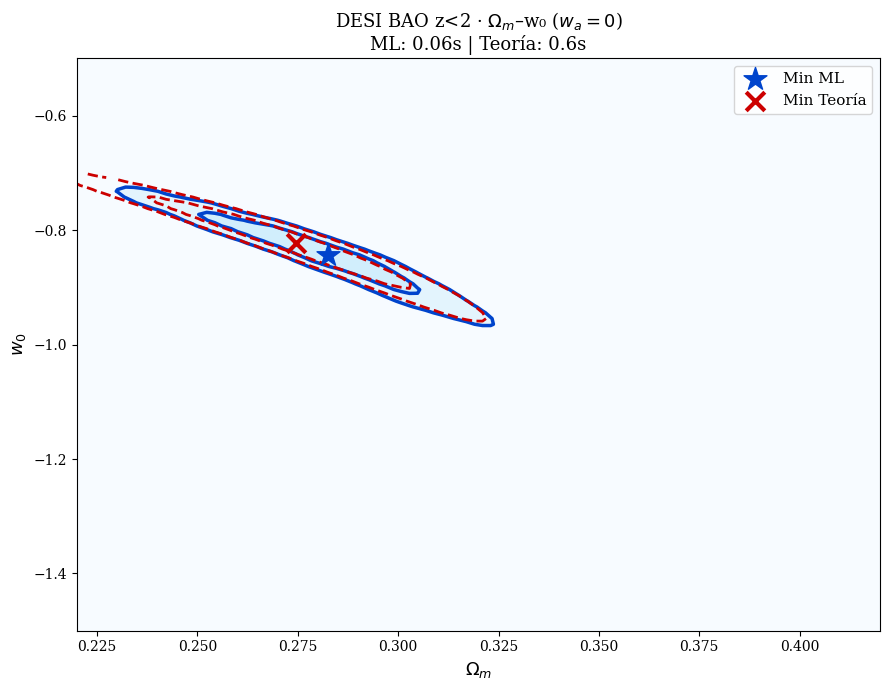

--- $w_a$ vs $\Omega_m$  ({'w0': -1.0}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_Om_wa.png


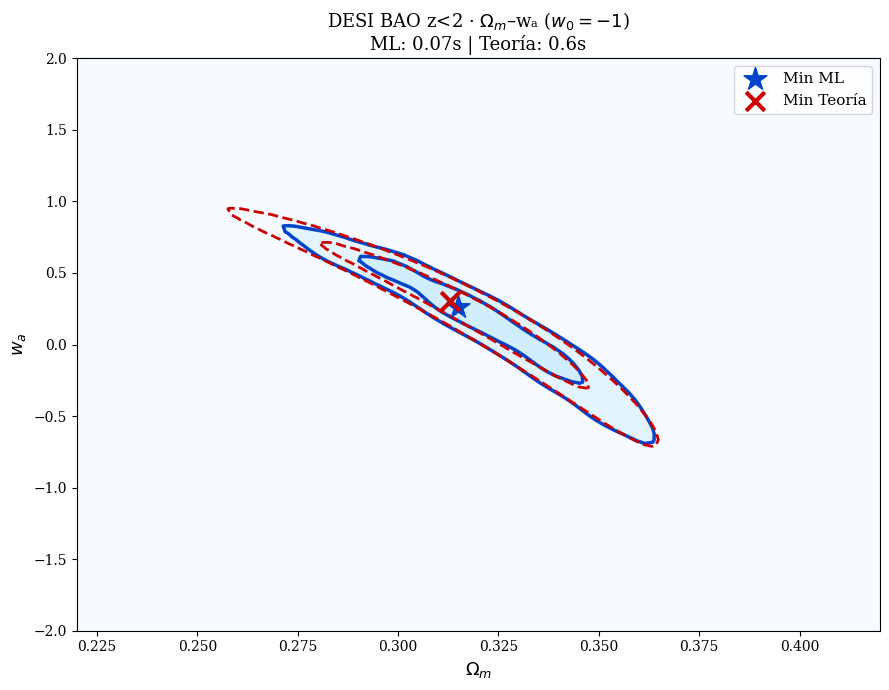

{'Z_ml': array([[3419.636   , 3387.0076  , 3325.4639  , ...,   59.799534,
           62.360924,   63.874626],
        [3401.027   , 3368.6116  , 3307.4912  , ...,   60.148888,
           62.773304,   64.32269 ],
        [3366.4395  , 3334.4233  , 3274.0808  , ...,   60.72797 ,
           63.457027,   65.06508 ],
        ...,
        [ 375.14673 ,  378.33255 ,  384.81223 , ..., 1579.6913  ,
         1592.2355  , 1599.3872  ],
        [ 403.99683 ,  407.1658  ,  413.60266 , ..., 1613.7972  ,
         1626.6174  , 1633.9502  ],
        [ 420.4349  ,  423.60522 ,  430.02856 , ..., 1632.9674  ,
         1645.945   , 1653.3804  ]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.0662977

In [24]:
common = dict(res=100, sigma=2.0, theory_threshold=12)

plot_contour_2d(
    model, features=FEATURES,
    x_param="w0", y_param="wa",
    x_range=(-1.4, -0.3), y_range=(-2.5, 1.5),
    fixed=dict(Om=REF["Om"]),
    theory_fn=chi2_fn,
    title=r"DESI BAO z<2 · w₀–wₐ ($\Omega_m=0.315$)",
    x_label=r"$w_0$", y_label=r"$w_a$",
    save_path=FIGURES_DIR / f"{SECTION}_w0_wa.png",
    show=True, **common,
)
plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w0",
    x_range=(0.22, 0.42), y_range=(-1.5, -0.5),
    fixed=dict(wa=0.0),
    theory_fn=chi2_fn,
    title=r"DESI BAO z<2 · $\Omega_m$–w₀ ($w_a=0$)",
    x_label=r"$\Omega_m$", y_label=r"$w_0$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_w0.png",
    show=True, **common,
)
plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="wa",
    x_range=(0.22, 0.42), y_range=(-2.0, 2.0),
    fixed=dict(w0=-1.0),
    theory_fn=chi2_fn,
    title=r"DESI BAO z<2 · $\Omega_m$–wₐ ($w_0=-1$)",
    x_label=r"$\Omega_m$", y_label=r"$w_a$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_wa.png",
    show=True, **common,
)

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_beeswarm.png


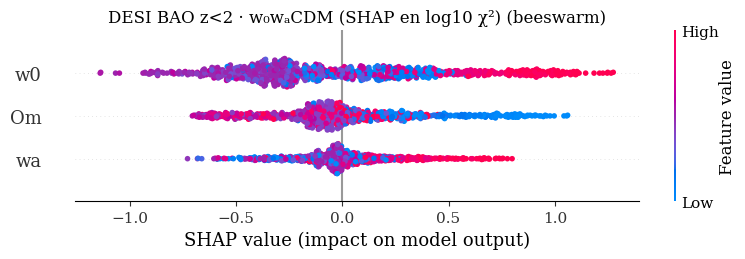

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_bar.png


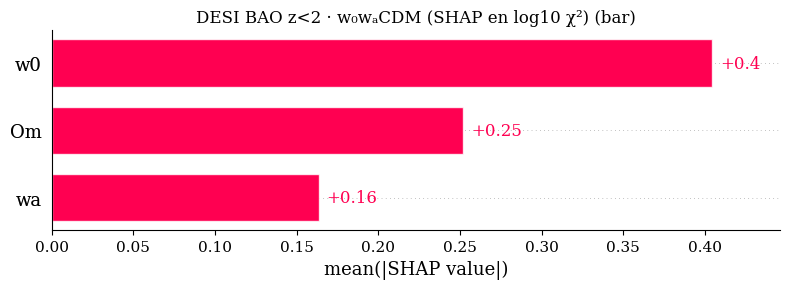

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_waterfall.png


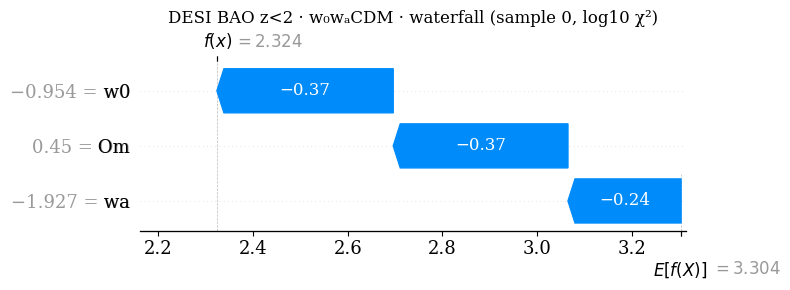

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_Om.png


<Figure size 640x480 with 0 Axes>

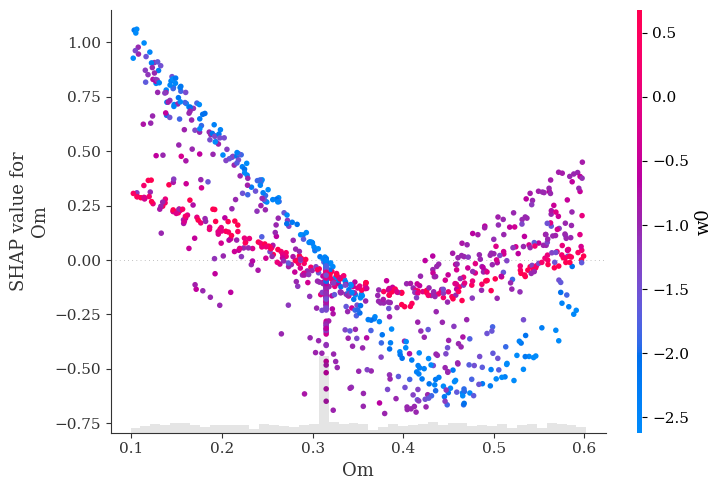

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_w0.png


<Figure size 640x480 with 0 Axes>

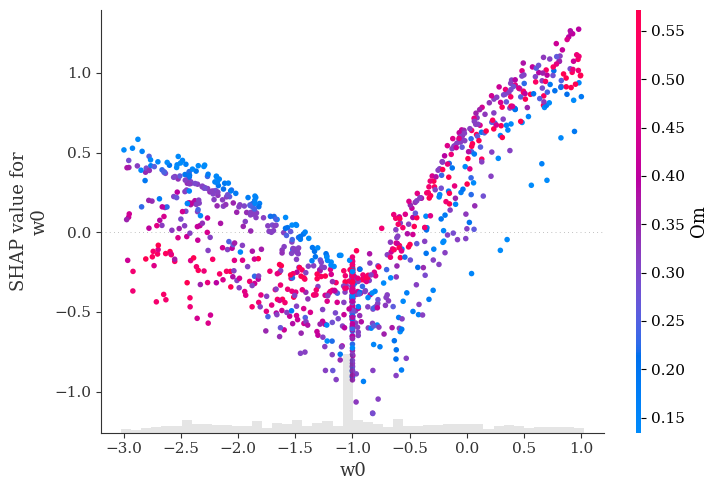

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_wa.png


<Figure size 640x480 with 0 Axes>

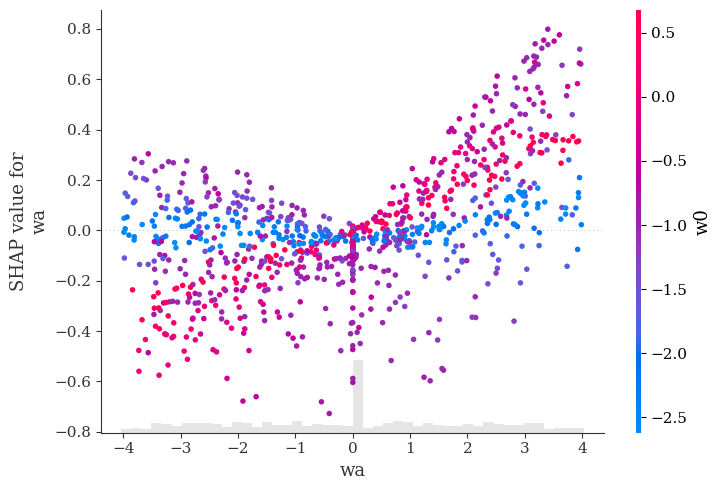

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_wa.png')]

In [25]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DESI BAO z<2 · w₀wₐCDM (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DESI BAO z<2 · w₀wₐCDM · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-5"></a>3.5 w₀wₐCDM + r_d=Planck (H₀ libre) — 4D

**Modelo:** `Flatw0waCDM` 4D (Ω_m, w₀, wₐ, H₀). r_d fijado al fiducial Planck (147.09 Mpc).
**Datos:** DESI BAO DR2.
**Por qué:** explorar la degeneración de H₀ con los demás parámetros cuando r_d viene de la inflación temprana (Planck). Sin priors externos, los datos BAO no fijan H₀ por sí solos cuando r_d ya está fijo, así que esperamos contornos anchos en H₀.

Refactor de `legacy/BAO_rdPlank/BAO_rdPlank_*`.

In [96]:
SECTION = "3_5"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0"]
REF = dict(Om=0.315, w0=-1.0, wa=0.0, H0=PLANCK_H0)

def chi2_fn(Om, w0, wa, H0):
    return chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0, rd=PLANCK_RD)

print(f"χ²(ΛCDM Planck) = {chi2_fn(**REF):.3f}")

χ²(ΛCDM Planck) = 30.681


In [97]:
def builder():
    N = 40_000
    pares = [('Om','w0'), ('Om','wa'), ('Om','H0'),
             ('w0','wa'), ('w0','H0'), ('wa','H0')]
    rangos = dict(Om=(0.1, 0.6), w0=(-2.5, 0.5), wa=(-4.0, 3.0), H0=(55, 85))
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=0,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min χ² = {df['chi2'].min():.3f}")

Cargando dataset existente: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_5_dataset.csv
min χ² = 8.392


In [98]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  cargando modelo cacheado: 3_5_model.ubj
  R²=0.99912 | best_iter=1256 | n_train=204,000 | n_val=36,000


  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_learning_curve.png


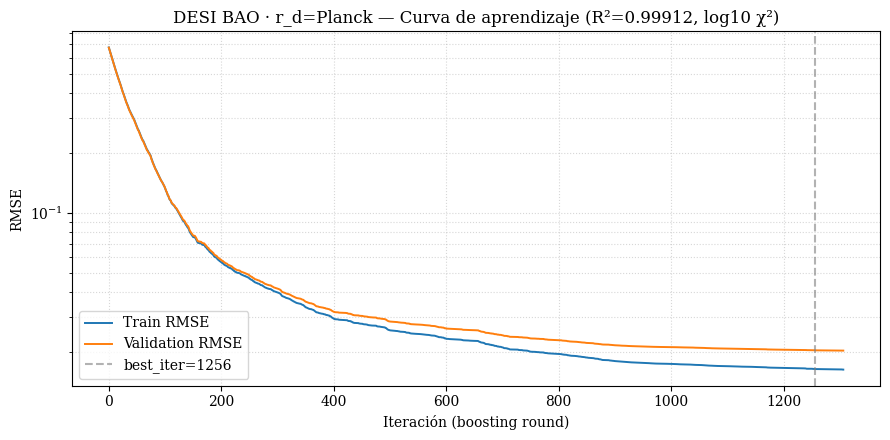

In [99]:
plot_learning_curve(
    info,
    title=f"DESI BAO · r_d=Planck — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w_0$ vs $\Omega_m$  ({'wa': 0.0, 'H0': 67.36}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_Om_w0.png


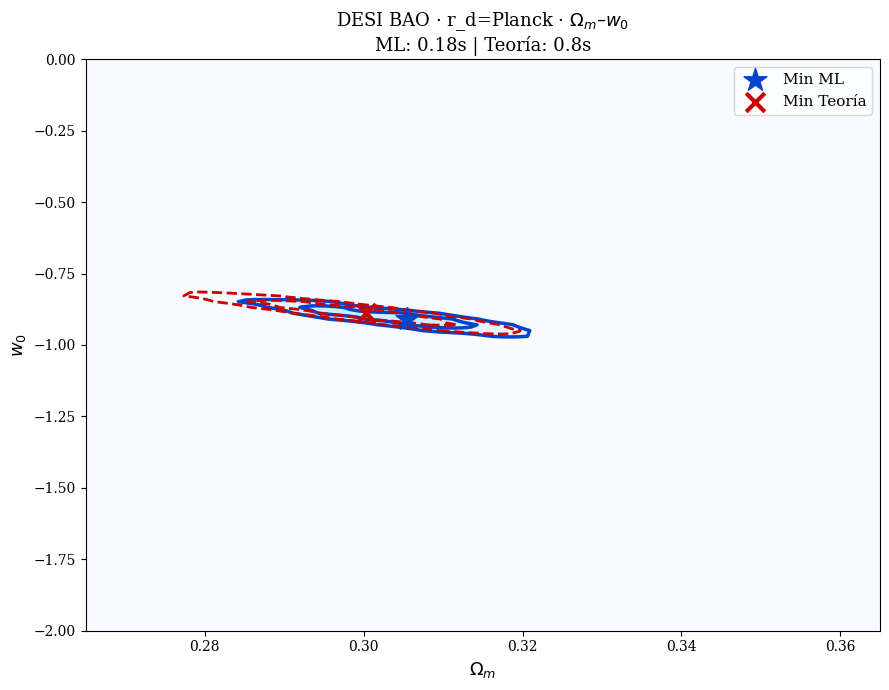

--- $w_a$ vs $\Omega_m$  ({'w0': -1.0, 'H0': 67.36}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_Om_wa.png


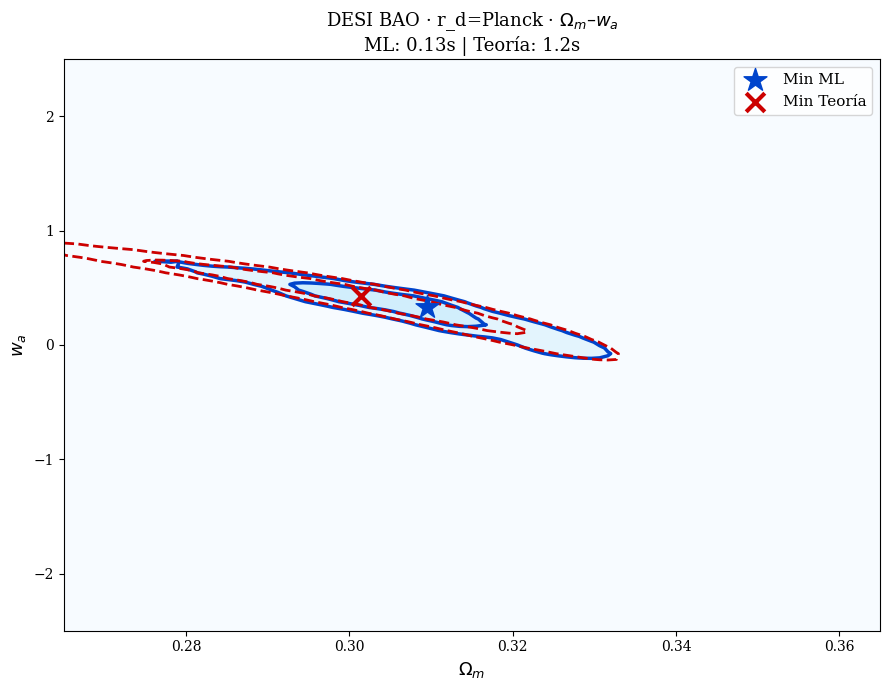

--- $H_0$ vs $\Omega_m$  ({'w0': -1.0, 'wa': 0.0}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_Om_H0.png


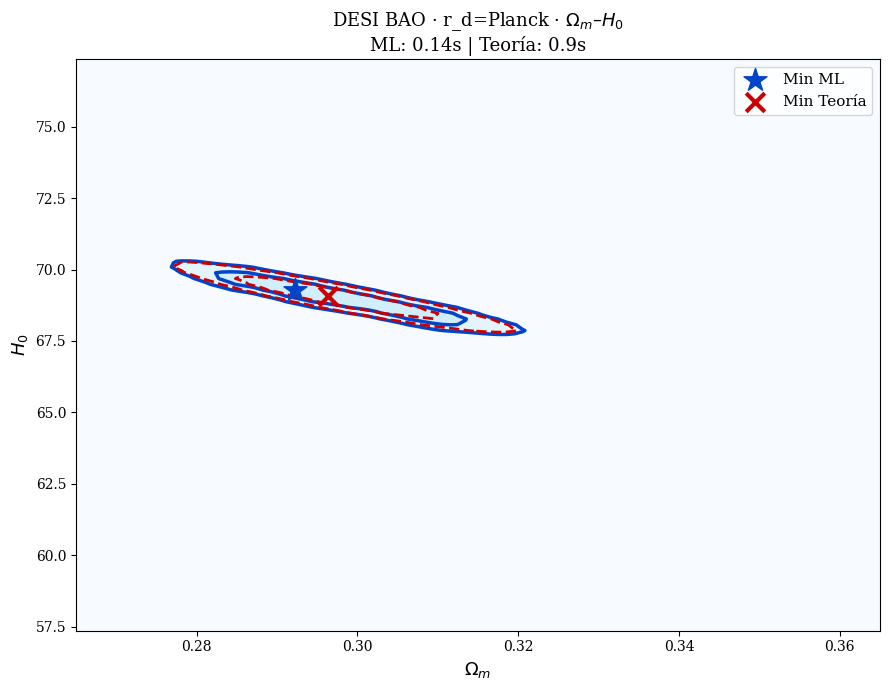

--- $w_a$ vs $w_0$  ({'Om': 0.315, 'H0': 67.36}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_w0_wa.png


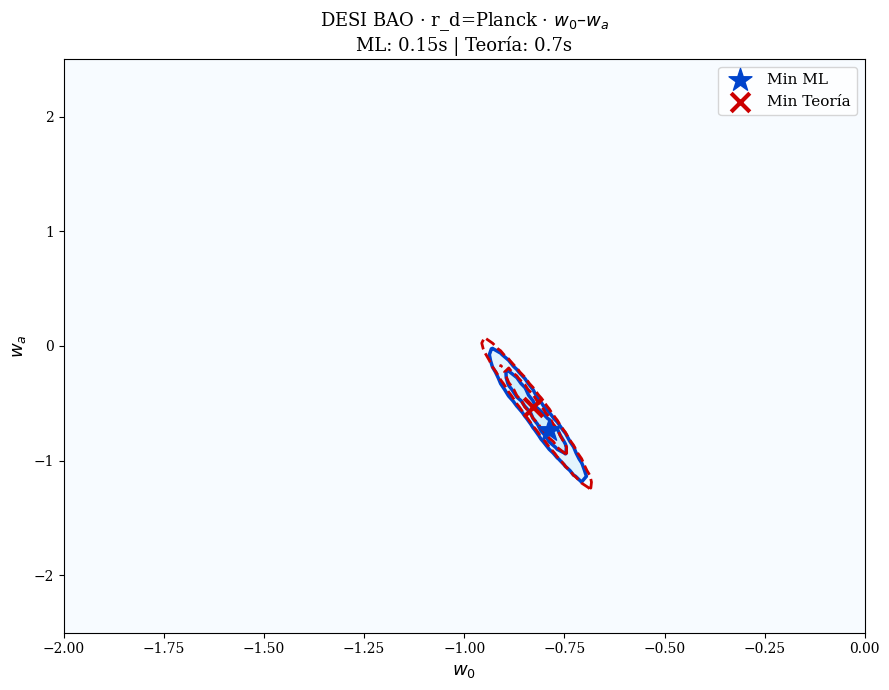

--- $H_0$ vs $w_0$  ({'Om': 0.315, 'wa': 0.0}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_w0_H0.png


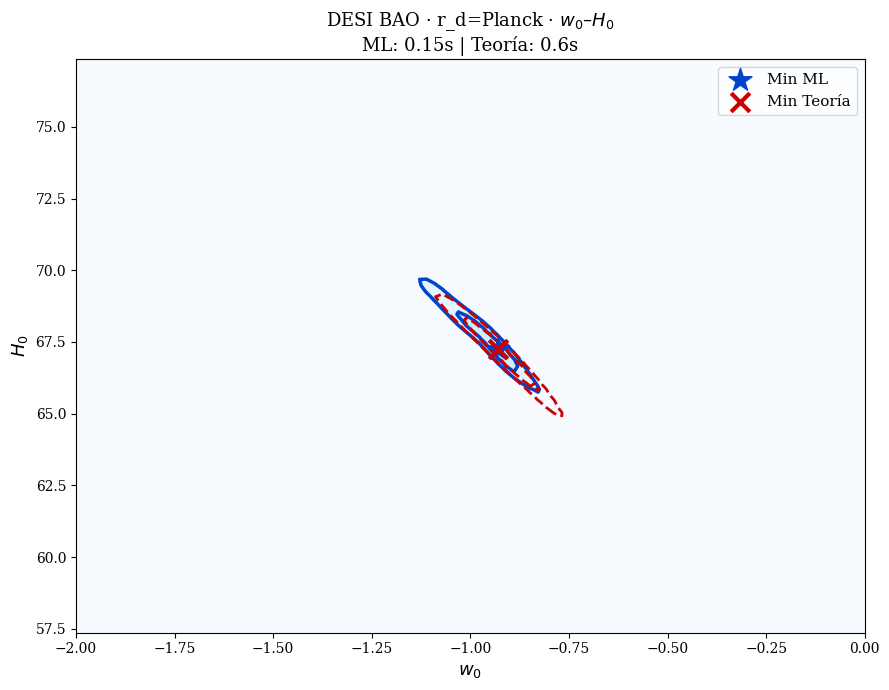

--- $H_0$ vs $w_a$  ({'Om': 0.315, 'w0': -1.0}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_wa_H0.png


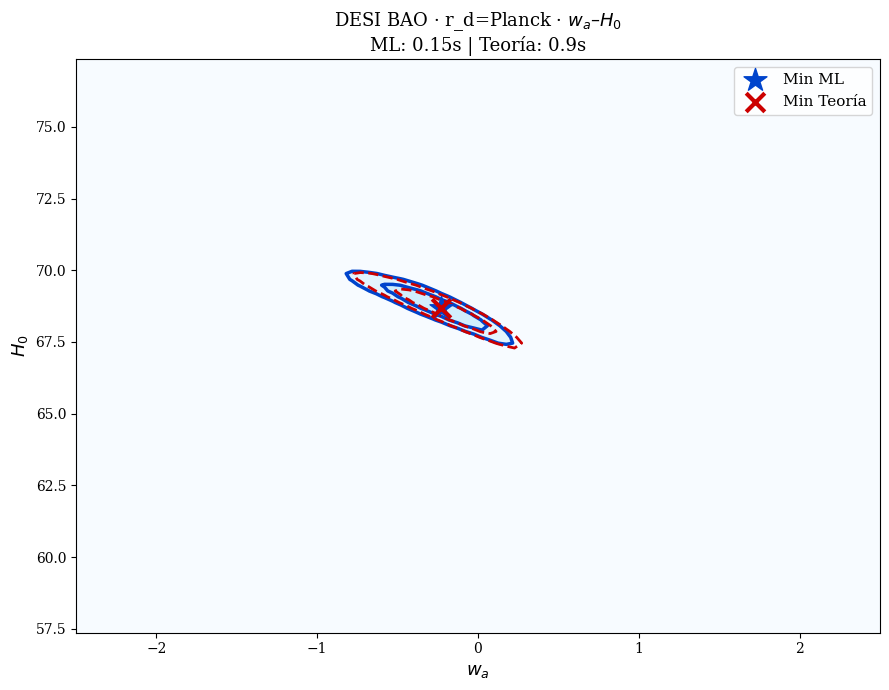

In [100]:
common = dict(res=100, sigma=2.0, theory_threshold=50)
RANGES = dict(
    Om=(REF['Om'] - 0.05, REF['Om'] + 0.05),
    w0=(REF['w0'] - 1.0,  REF['w0'] + 1.0),
    wa=(REF['wa'] - 2.5,  REF['wa'] + 2.5),
    H0=(REF['H0'] - 10,   REF['H0'] + 10),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$", H0=r"$H_0$")

for x, y in [('Om','w0'), ('Om','wa'), ('Om','H0'),
             ('w0','wa'), ('w0','H0'), ('wa','H0')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DESI BAO · r_d=Planck · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
    )

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_beeswarm.png


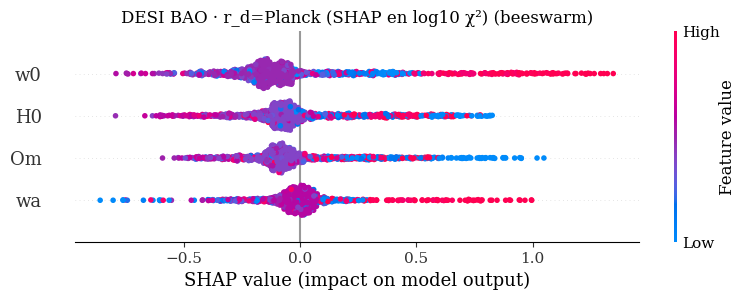

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_bar.png


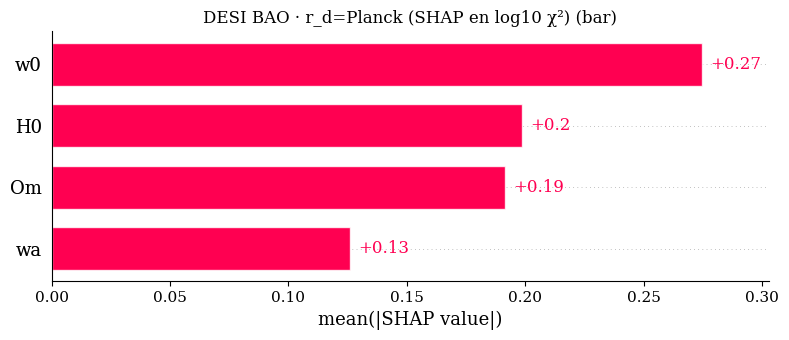

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_waterfall.png


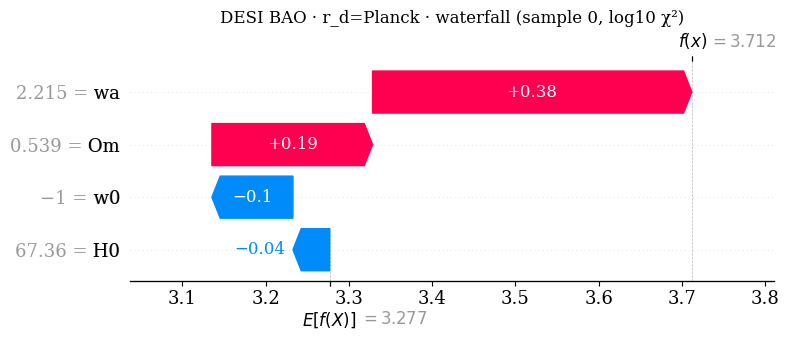

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_Om.png


<Figure size 640x480 with 0 Axes>

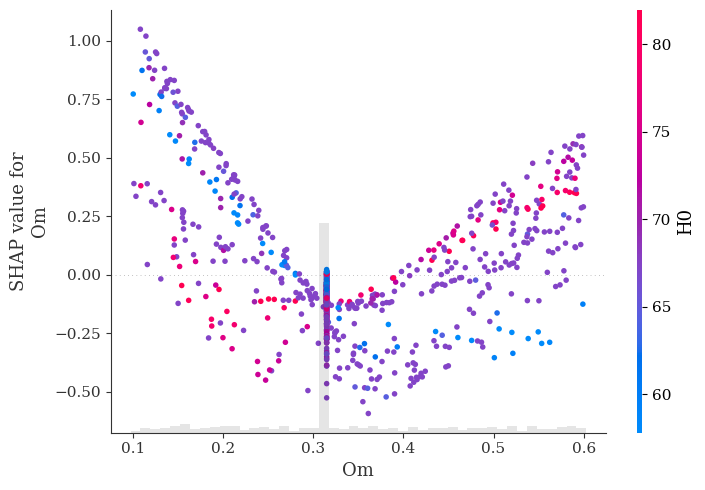

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_w0.png


<Figure size 640x480 with 0 Axes>

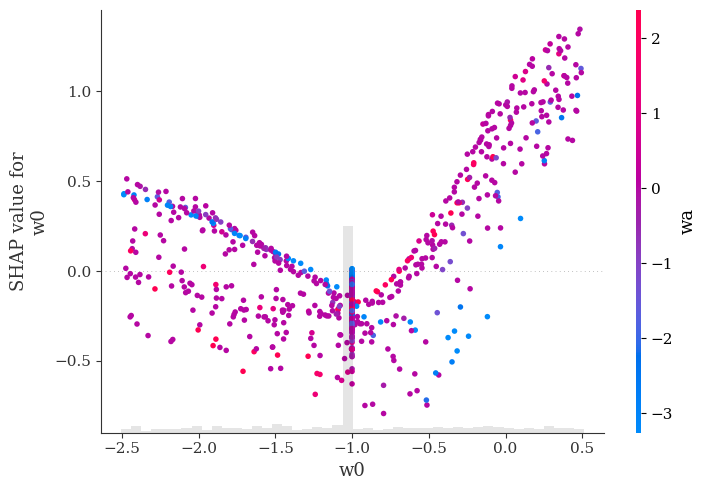

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_wa.png


<Figure size 640x480 with 0 Axes>

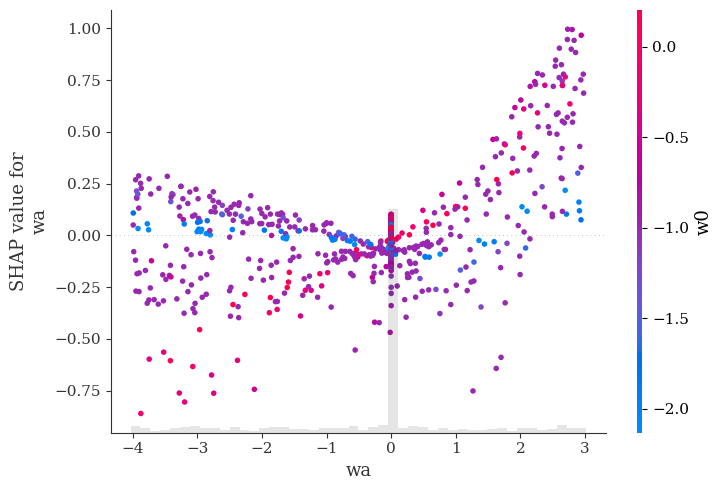

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_H0.png


<Figure size 640x480 with 0 Axes>

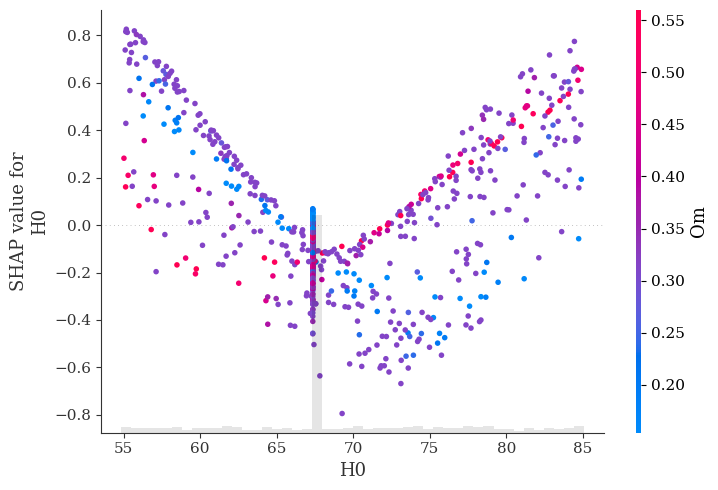

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_H0.png')]

In [31]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DESI BAO · r_d=Planck (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DESI BAO · r_d=Planck · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-6"></a>3.6 w₀wₐCDM con H₀·r_d (BAO-only) — 4D

**Modelo:** `Flatw0waCDM` 4D (Ω_m, w₀, wₐ, H₀·r_d).
**Datos:** DESI BAO DR2.
**Por qué:** el χ² BAO **sólo depende del producto H₀·r_d**, no de cada uno por separado. Esto se ve en la fórmula de las distancias: DM/r_d = (c/H₀)·I(z)/r_d = (c/(H₀·r_d))·I(z), e idem para DH/r_d y DV/r_d. Por tanto la combinación H₀·r_d es el observable BAO **directo** y único. Esta sección lo demuestra: tratamos H₀·r_d como un único parámetro.

En `chi2_bao` se traduce a `H0=H0_rd, rd=1.0`. Refactor de `legacy/BAO_H0rd/BAO_H0rd_*`.

In [59]:
SECTION = "3_6"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0_rd"]
REF = dict(Om=0.315, w0=-1.0, wa=0.0, H0_rd=PLANCK_H0 * PLANCK_RD)
print(f"H0·rd Planck = {REF['H0_rd']:.1f}")

def chi2_fn(Om, w0, wa, H0_rd):
    return chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0_rd, rd=1.0)

print(f"χ²(ΛCDM Planck) = {chi2_fn(**REF):.3f}")

H0·rd Planck = 9908.0
χ²(ΛCDM Planck) = 30.681


In [91]:
def builder():
    N = 5_000
    pares = [('Om','w0'), ('Om','wa'), ('Om','H0_rd'),
             ('w0','wa'), ('w0','H0_rd'), ('wa','H0_rd')]
    rangos = dict(Om=(0.1, 0.6), w0=(-2.5, 0.5), wa=(-4.0, 3.0), H0_rd=(8500, 11500))
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=10000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=True)
print(f"min χ² = {df['chi2'].min():.3f}")

Generando dataset (no existe /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_6_dataset.csv)...
Calculando χ² para 30000 puntos (en paralelo)...
  → terminado en 4.8s
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_6_dataset.csv  (30000 filas)
min χ² = 5.627


In [92]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  cargando modelo cacheado: 3_6_model.ubj
  R²=0.99010 | best_iter=970 | n_train=33,953 | n_val=5,992


  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_learning_curve.png


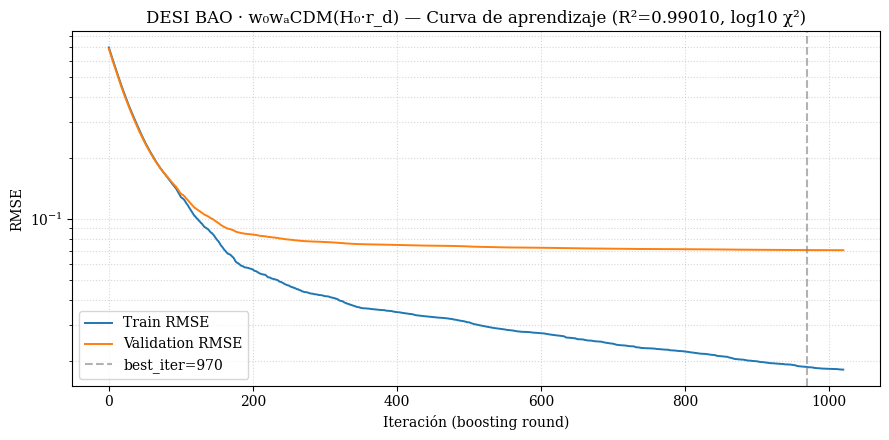

In [93]:
plot_learning_curve(
    info,
    title=f"DESI BAO · w₀wₐCDM(H₀·r_d) — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w_0$ vs $\Omega_m$  ({'wa': -2.661441939809399, 'H0_rd': 9142.884772270527}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_Om_w0.png


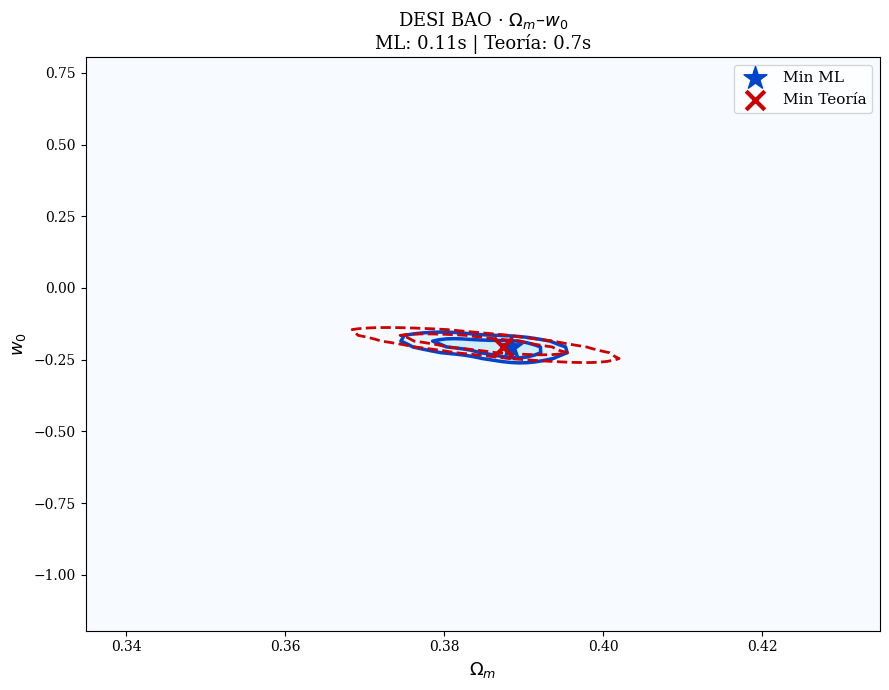

--- $w_a$ vs $\Omega_m$  ({'w0': -0.19548972514691287, 'H0_rd': 9142.884772270527}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_Om_wa.png


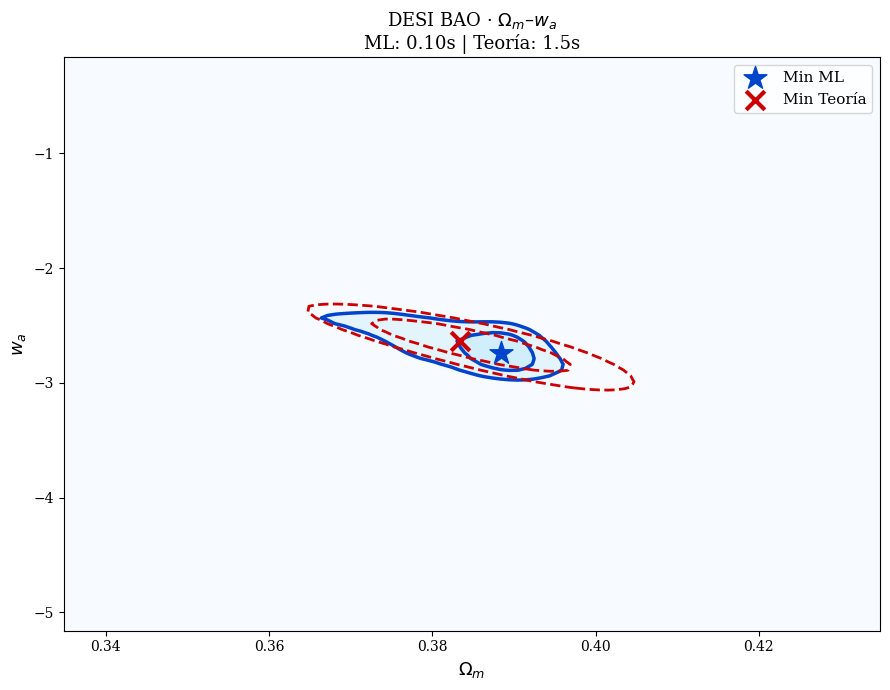

--- $H_0 \cdot r_d$ vs $\Omega_m$  ({'w0': -0.19548972514691287, 'wa': -2.661441939809399}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_Om_H0_rd.png


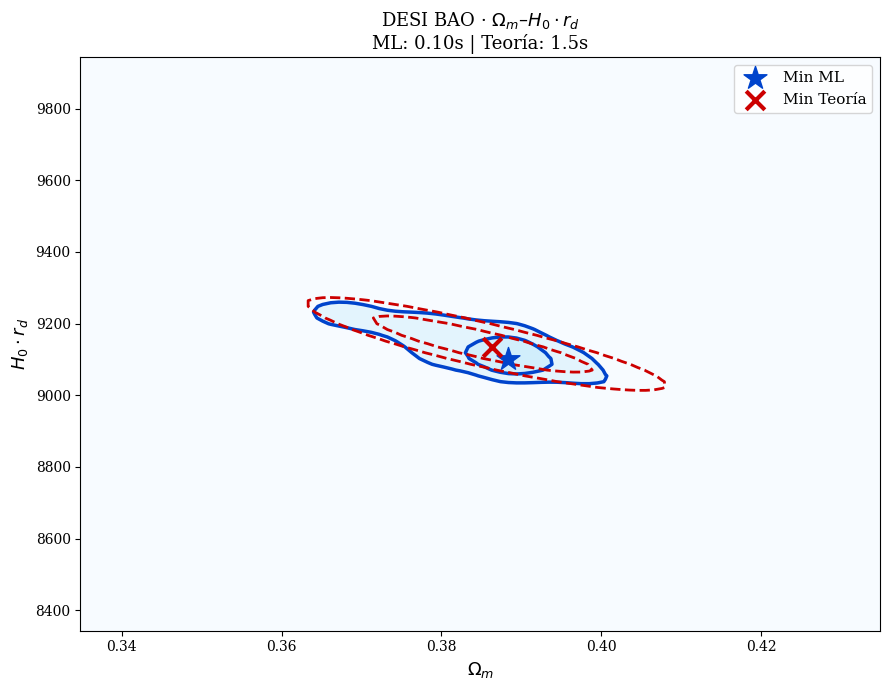

--- $w_a$ vs $w_0$  ({'Om': 0.3848438679435711, 'H0_rd': 9142.884772270527}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_w0_wa.png


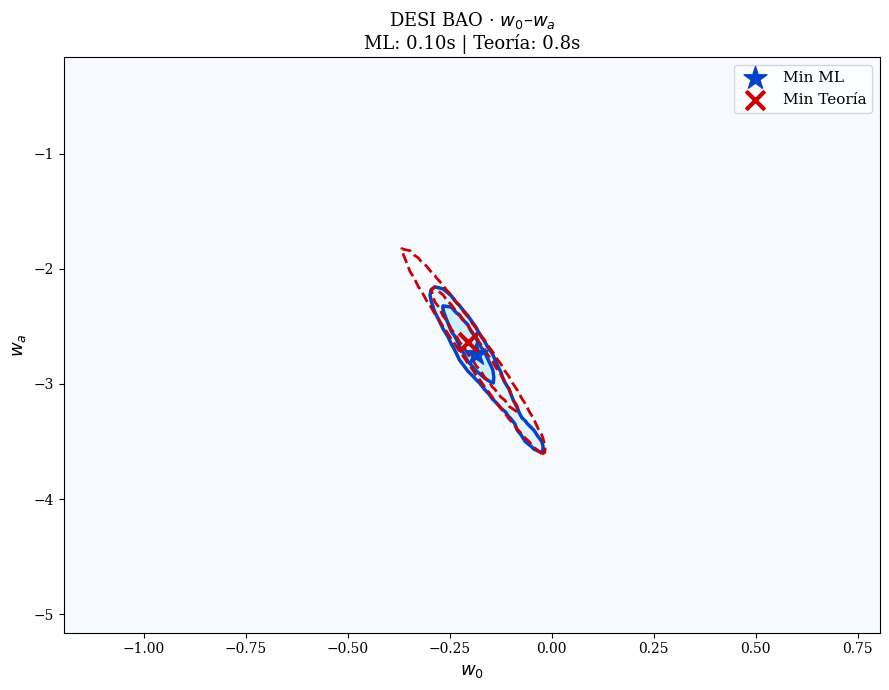

--- $H_0 \cdot r_d$ vs $w_0$  ({'Om': 0.3848438679435711, 'wa': -2.661441939809399}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_w0_H0_rd.png


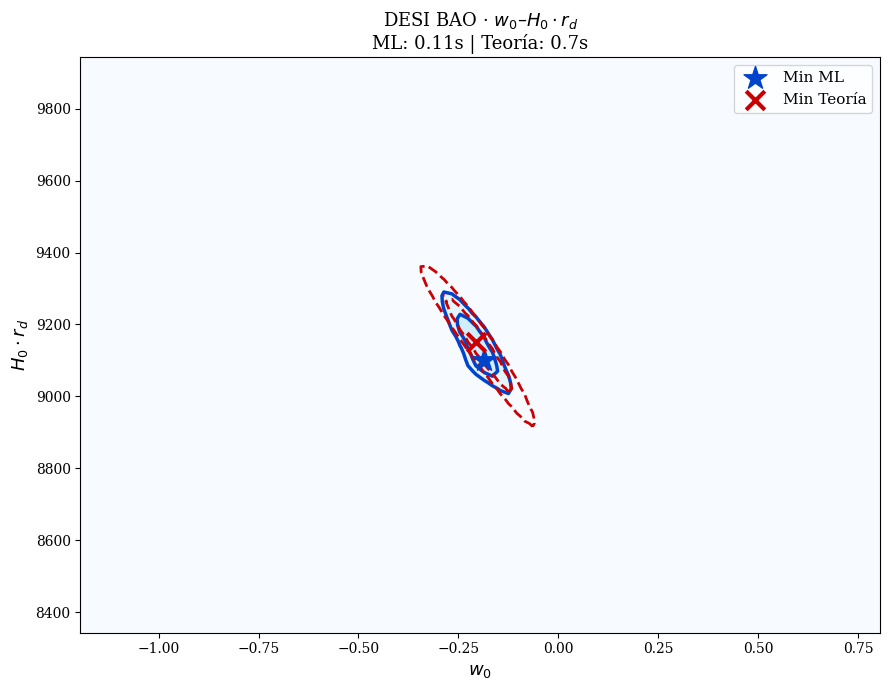

--- $H_0 \cdot r_d$ vs $w_a$  ({'Om': 0.3848438679435711, 'w0': -0.19548972514691287}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_wa_H0_rd.png


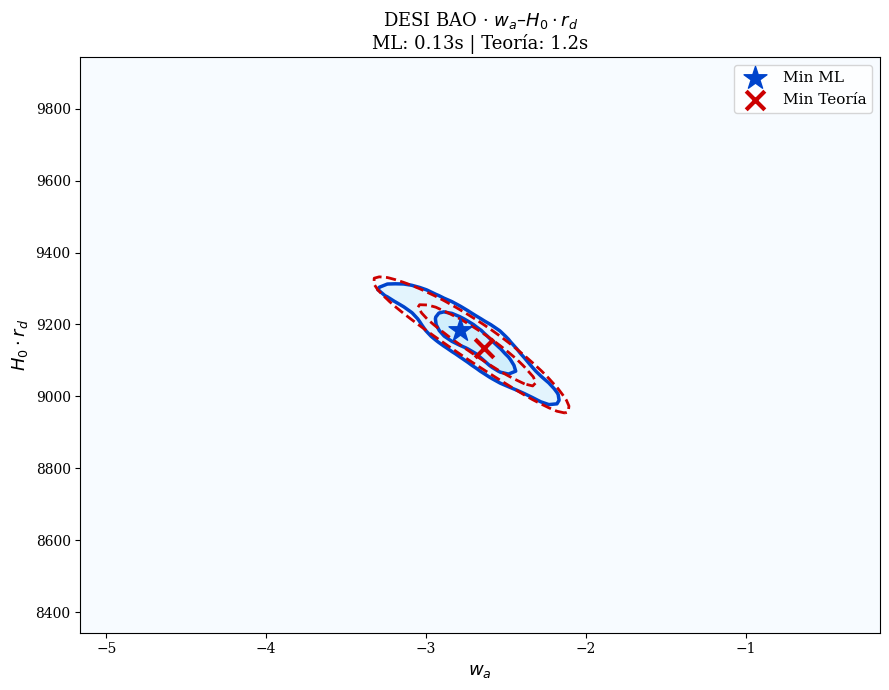

In [94]:
common = dict(res=100, sigma=2.0, theory_threshold=50)
RANGES = dict(
    Om=(REF['Om'] - 0.05,    REF['Om'] + 0.05),
    w0=(REF['w0'] - 1.0,     REF['w0'] + 1.0),
    wa=(REF['wa'] - 2.5,     REF['wa'] + 2.5),
    H0_rd=(REF['H0_rd'] - 800, REF['H0_rd'] + 800),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$", H0_rd=r"$H_0 \cdot r_d$")

for x, y in [('Om','w0'), ('Om','wa'), ('Om','H0_rd'),
             ('w0','wa'), ('w0','H0_rd'), ('wa','H0_rd')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DESI BAO · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
    )

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_beeswarm.png


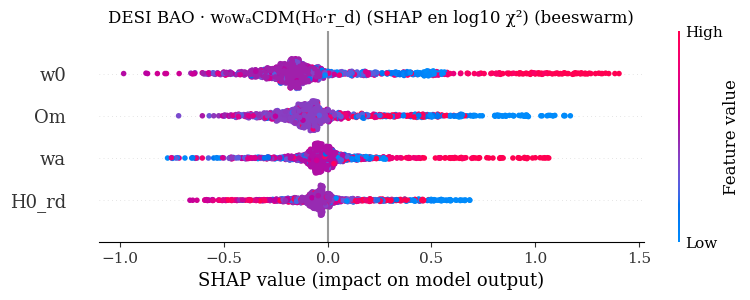

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_bar.png


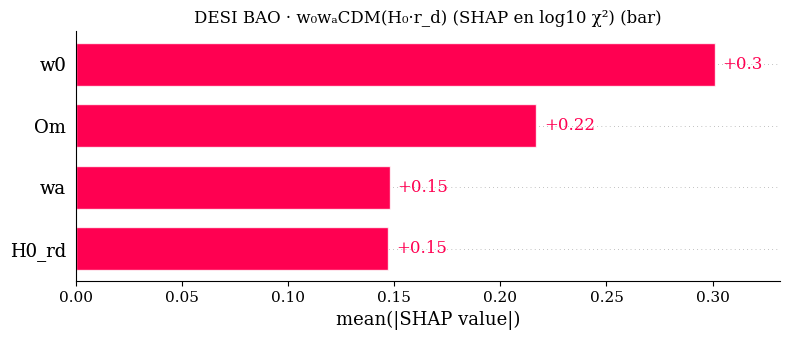

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_waterfall.png


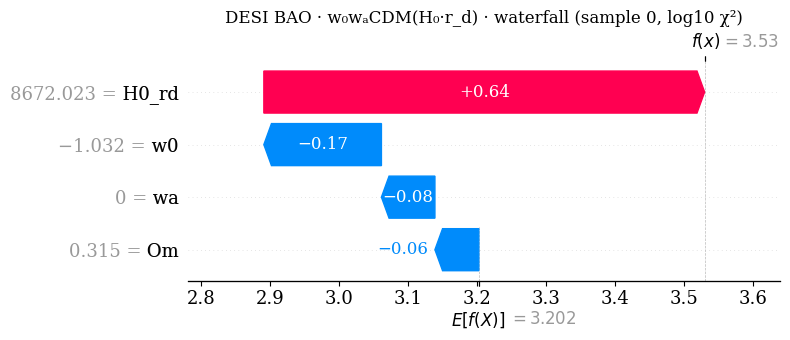

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_Om.png


<Figure size 640x480 with 0 Axes>

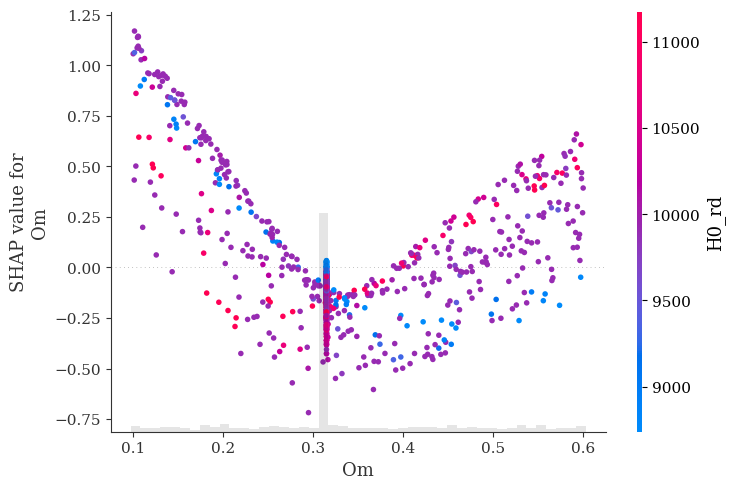

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_w0.png


<Figure size 640x480 with 0 Axes>

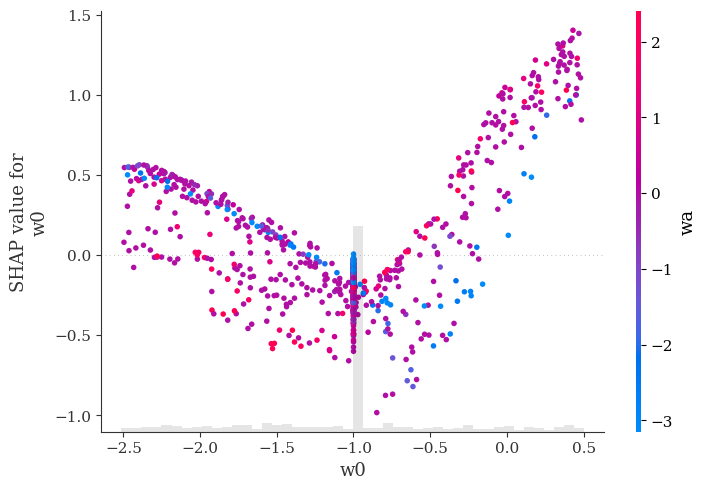

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_wa.png


<Figure size 640x480 with 0 Axes>

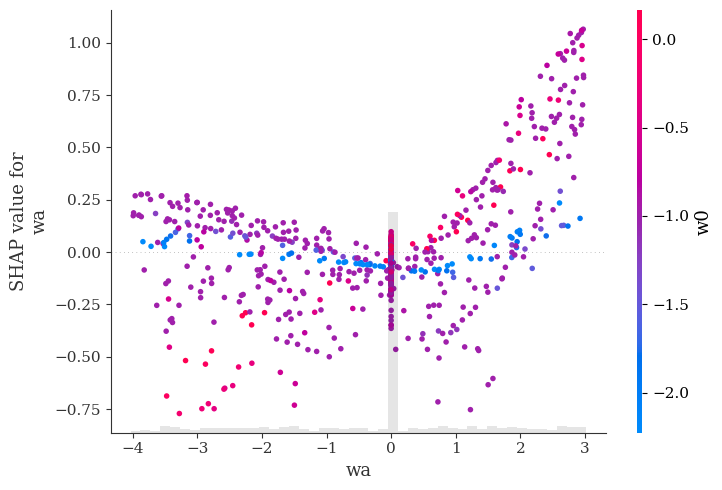

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_H0_rd.png


<Figure size 640x480 with 0 Axes>

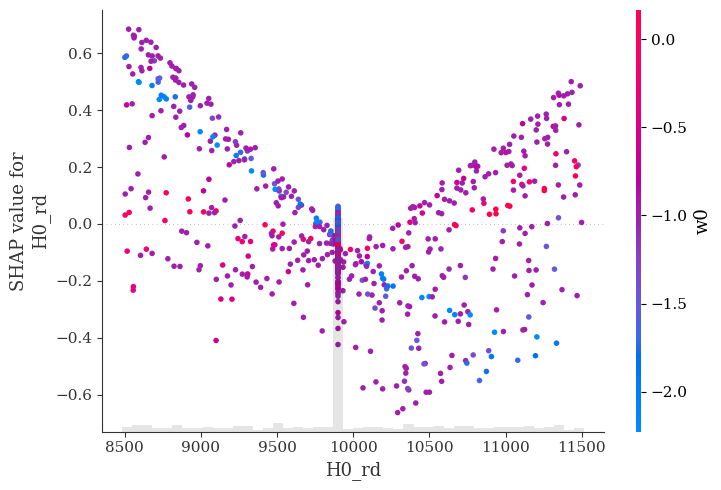

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_H0_rd.png')]

In [37]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DESI BAO · w₀wₐCDM(H₀·r_d) (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DESI BAO · w₀wₐCDM(H₀·r_d) · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-7"></a>3.7 Degeneración H₀–r_d (SHAP) — 5D sin priors

**Modelo:** `Flatw0waCDM` 5D (Ω_m, w₀, wₐ, H₀, r_d).
**Datos:** DESI BAO DR2, 40k puntos random puros (sin slices, sin priors).
**Por qué:** mostrar VISUALMENTE con SHAP que BAO **no restringe H₀ y r_d por separado**, sólo el producto H₀·r_d (lo que demostramos analíticamente en §3.6). Esperamos en la lectura SHAP:
- Importancia de Ω_m, w₀, wₐ: **alta** (los datos sí los restringen).
- Importancia de H₀ y r_d por separado: **moderada-baja** y **anti-correlacionados** en los dependence plots → la degeneración perfecta.

NO entrenamos contornos — el punto del escenario es la lectura SHAP de la degeneración. Refactor de `legacy/BAO_SHAP_H0RDH0/H0rd_H0_*`.

In [38]:
SECTION = "3_7"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0", "rd"]
REF = dict(Om=PLANCK_OM, w0=-1.0, wa=0.0, H0=PLANCK_H0, rd=PLANCK_RD)

def chi2_fn(Om, w0, wa, H0, rd):
    return chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0, rd=rd)

print(f"χ²(LCDM Planck) = {chi2_fn(**REF):.3f}")

χ²(LCDM Planck) = 30.155


In [39]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        random_box=dict(
            Om=(0.20, 0.40), w0=(-1.5, -0.5), wa=(-1.5, 1.0),
            H0=(60, 75), rd=(140, 155),
        ),
        n_random=40_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min χ² = {df['chi2'].min():.3f}")

Cargando dataset existente: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_7_dataset.csv
min χ² = 8.116


  descartando 290 filas con chi² >= 90000.0 (fallos integración)
  target en Shifted-Log10: rango [0.000, 4.954]
  entrenamiento: 13.67s | R²=0.93400 | best_iter=743/3000  (early stop, ahorro ~75%)
  modelo cacheado: 3_7_model.ubj
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_learning_curve.png


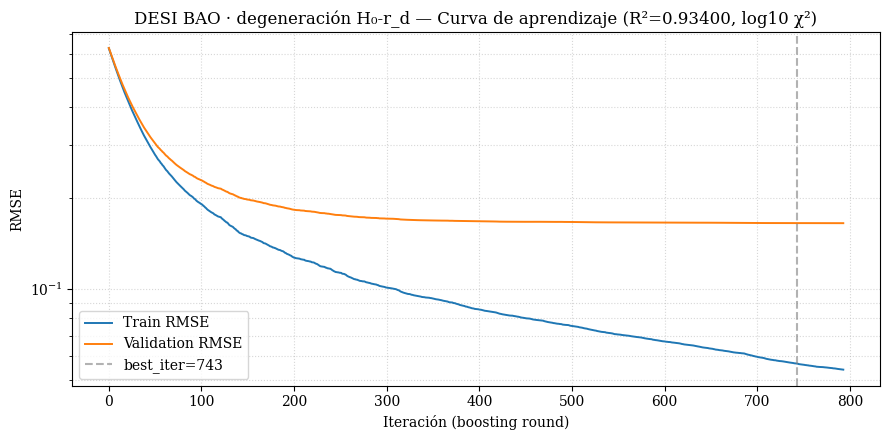

In [40]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"DESI BAO · degeneración H₀-r_d — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

### Lectura de la degeneración

El plot de **bar** ordena los features por importancia media. Esperamos w₀, wₐ y Ω_m por encima de H₀ y r_d (que estarán intermedios o bajos por separado).

Los **dependence plots** de H₀ y r_d deberían mostrar dispersión alta en color (interacciones fuertes con el otro) — es la huella de la degeneración H₀·r_d.

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_beeswarm.png


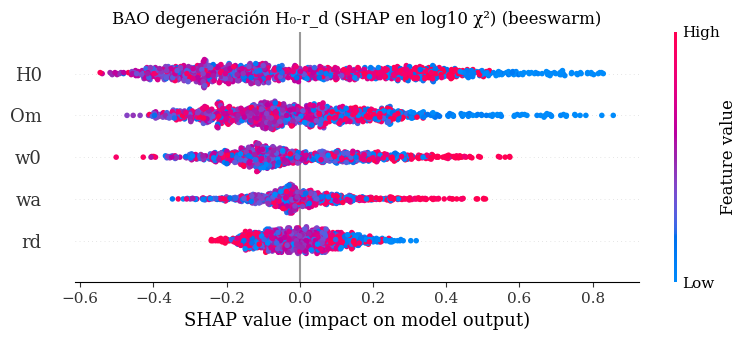

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_bar.png


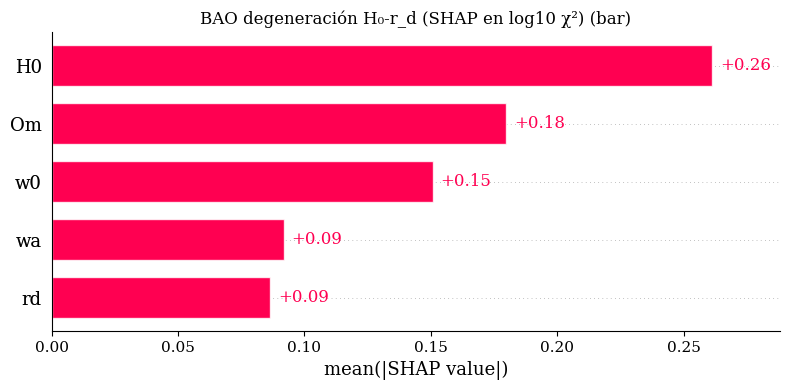

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_waterfall.png


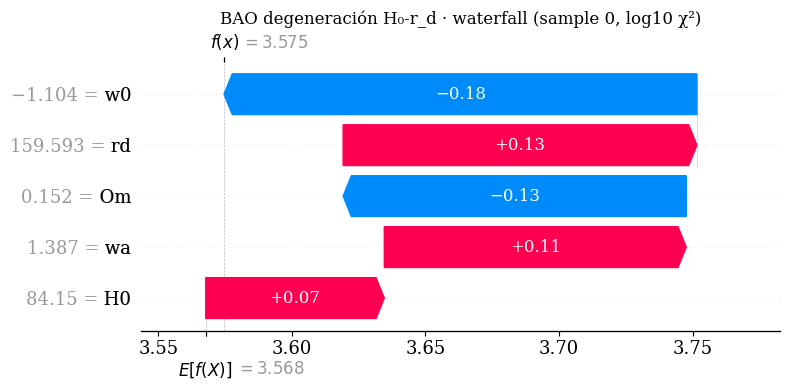

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_Om.png


<Figure size 640x480 with 0 Axes>

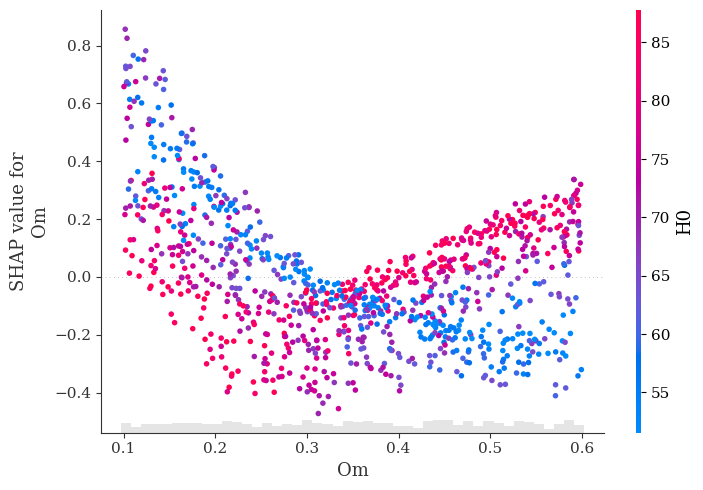

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_w0.png


<Figure size 640x480 with 0 Axes>

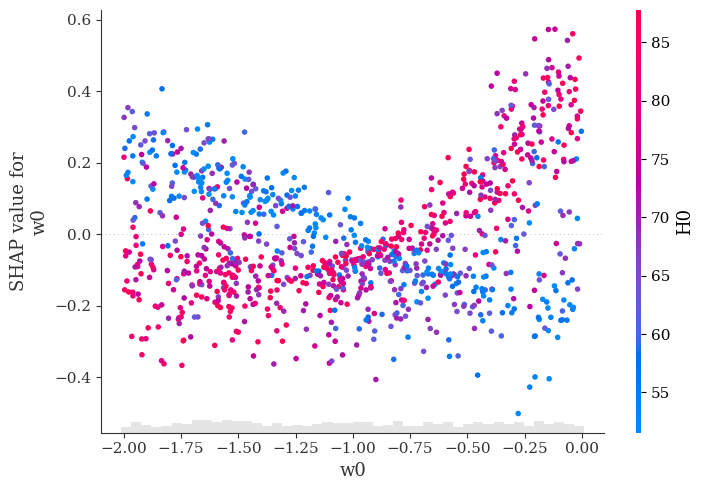

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_wa.png


<Figure size 640x480 with 0 Axes>

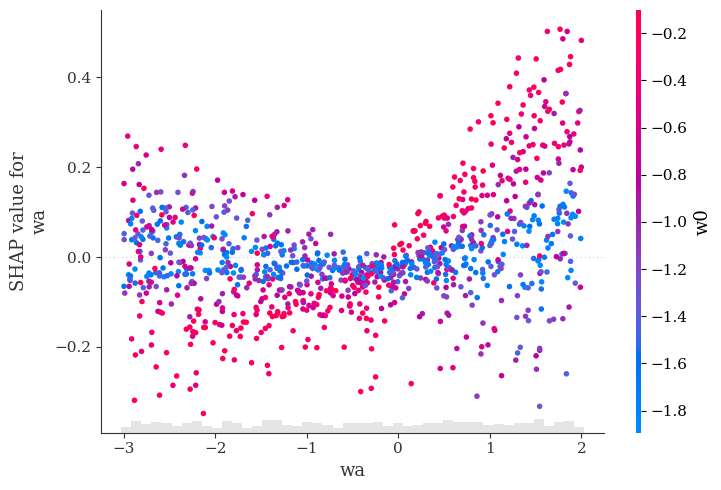

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_H0.png


<Figure size 640x480 with 0 Axes>

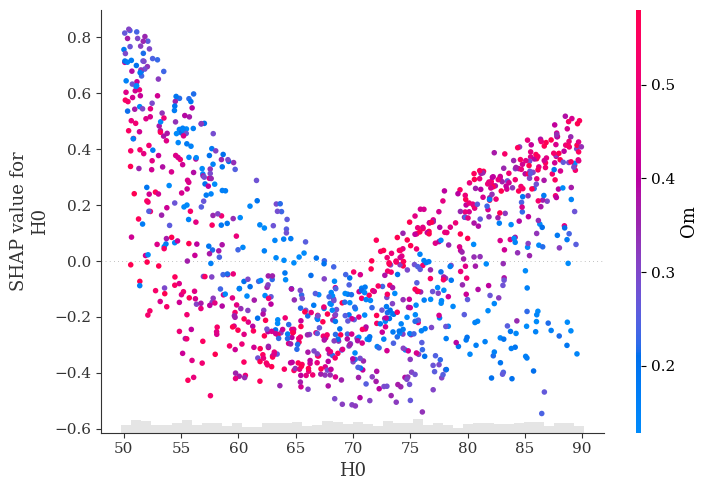

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_rd.png


<Figure size 640x480 with 0 Axes>

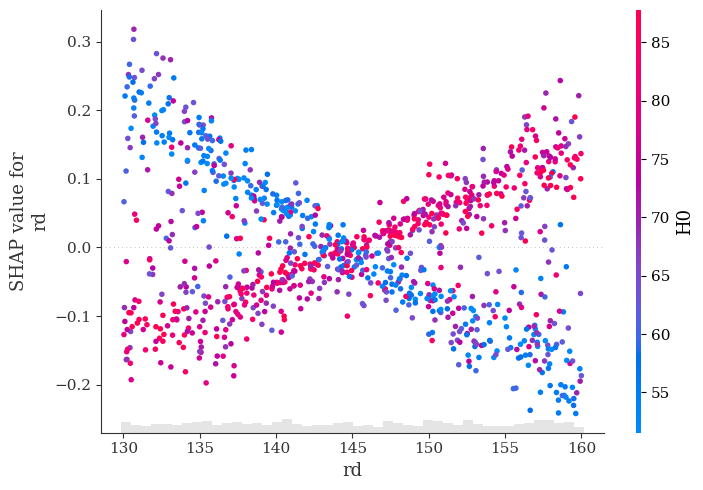

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_rd.png')]

In [41]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="BAO degeneración H₀-r_d (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="BAO degeneración H₀-r_d · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-8"></a>3.8 w₀wₐCDM + Planck priors en Ω_m/H₀/r_d — 5D

**Modelo:** `Flatw0waCDM` 5D (Ω_m, w₀, wₐ, H₀, r_d).
**Datos:** DESI BAO DR2 + priors gaussianos de Planck 2018 sobre (Ω_m, H₀, r_d). w₀ y wₐ libres.
**Por qué:** combinar BAO con la cosmología temprana (Planck) sin asumir nada sobre la energía oscura. Esto ata Ω_m/H₀/r_d a sus valores Planck y permite ver cómo BAO restringe (w₀, wₐ) condicionalmente.

Priors: Ω_m=0.3153±0.0073, H₀=67.36±0.54, r_d=147.09±0.26 (los tres en `cosmoml.priors.planck_prior_chi2`).

Refactor de `legacy/BAO_PlankPriors/BAO_PlankPriors_*`.

In [42]:
SECTION = "3_8"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0", "rd"]
REF = dict(Om=PLANCK_OM, w0=-1.0, wa=0.0, H0=PLANCK_H0, rd=PLANCK_RD)

def chi2_fn(Om, w0, wa, H0, rd):
    return (chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0, rd=rd)
            + planck_prior_chi2(Om=Om, H0=H0, rd=rd))

print(f"χ²(REF) = {chi2_fn(**REF):.3f}  (= χ²_BAO con todo en Planck; los priors aportan 0)")

χ²(REF) = 30.155  (= χ²_BAO con todo en Planck; los priors aportan 0)


In [43]:
def builder():
    N = 40_000
    pares = [('Om','w0'), ('Om','wa'), ('Om','H0'),
             ('w0','wa'), ('w0','H0'), ('wa','H0')]
    rangos = dict(Om=(0.1, 0.6), w0=(-2.5, 0.5), wa=(-4.0, 3.0),
                  H0=(60, 75), rd=(140, 155))
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=0,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min χ² = {df['chi2'].min():.3f}")

Cargando dataset existente: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_8_dataset.csv
min χ² = 8.420


In [44]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  target en Shifted-Log10: rango [0.000, 4.666]
  entrenamiento: 21.44s | R²=0.99932 | best_iter=977/3000  (early stop, ahorro ~67%)
  modelo cacheado: 3_8_model.ubj


  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_learning_curve.png


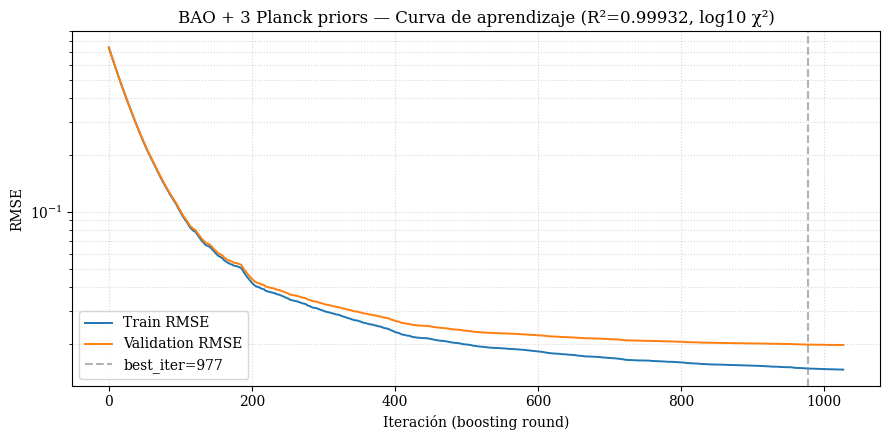

In [45]:
plot_learning_curve(
    info,
    title=f"BAO + 3 Planck priors — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w_0$ vs $\Omega_m$  ({'wa': -0.2767425261625964, 'H0': 67.47900511267325, 'rd': 147.1026385992456}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_Om_w0.png


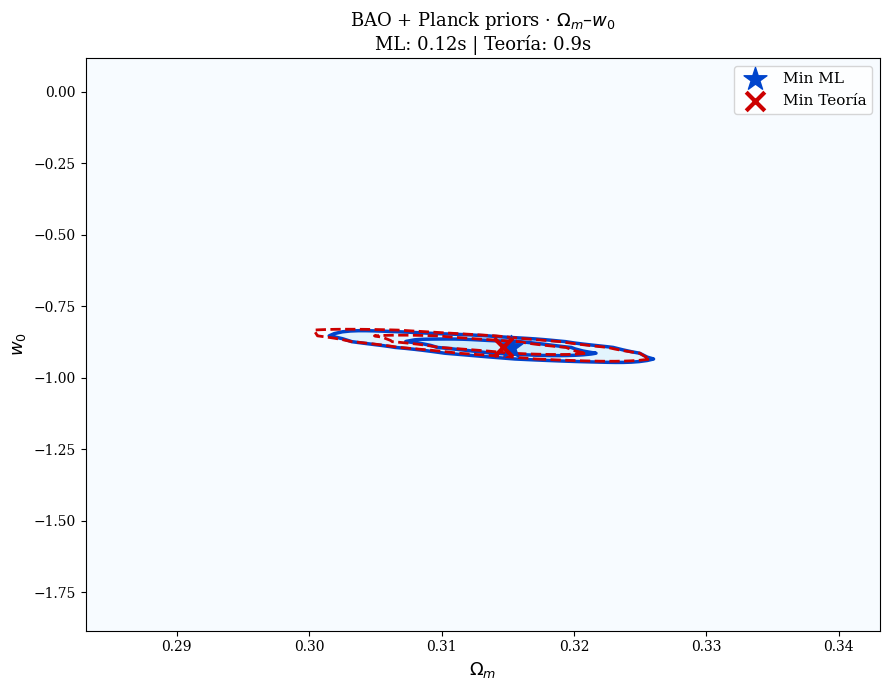

--- $w_a$ vs $\Omega_m$  ({'w0': -0.8837552582302637, 'H0': 67.47900511267325, 'rd': 147.1026385992456}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_Om_wa.png


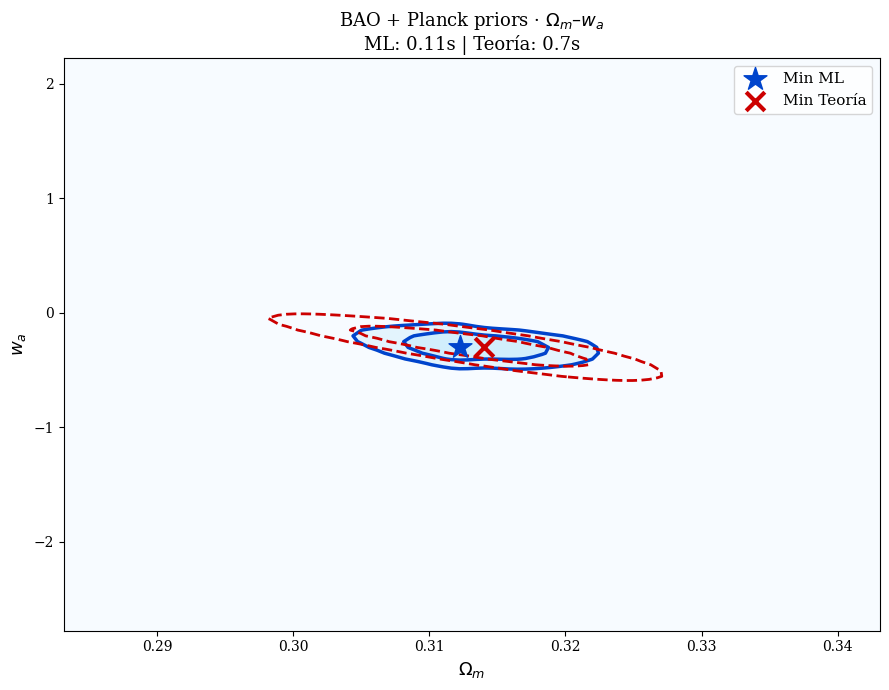

--- $H_0$ vs $\Omega_m$  ({'w0': -0.8837552582302637, 'wa': -0.2767425261625964, 'rd': 147.1026385992456}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_Om_H0.png


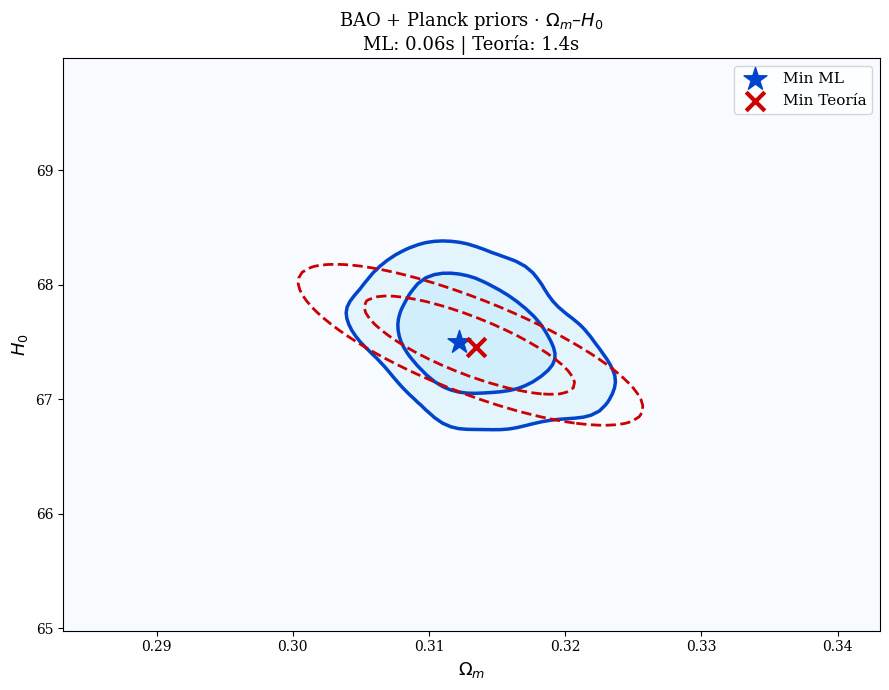

--- $w_a$ vs $w_0$  ({'Om': 0.3131189944418702, 'H0': 67.47900511267325, 'rd': 147.1026385992456}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_w0_wa.png


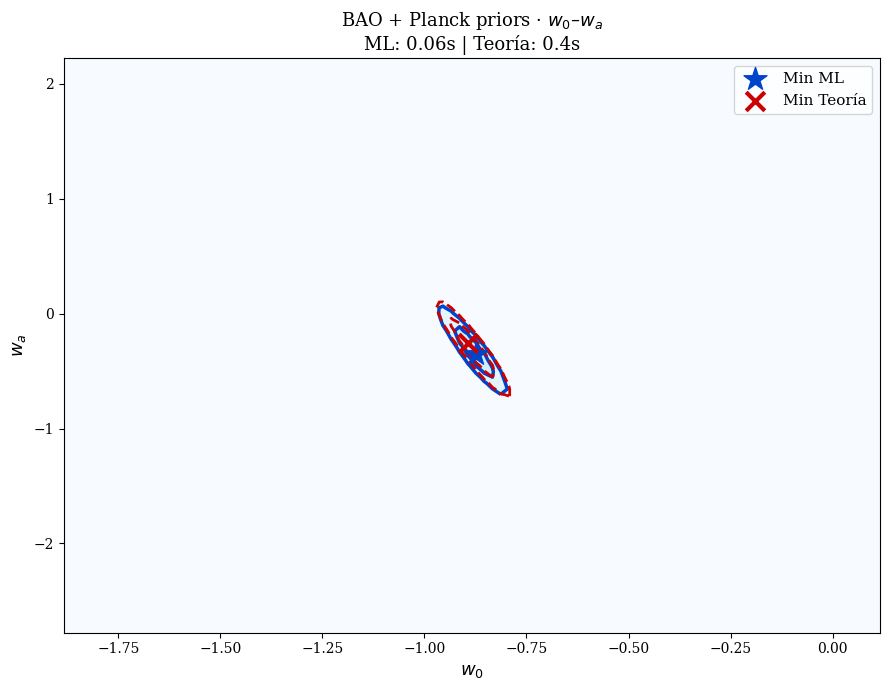

--- $H_0$ vs $w_0$  ({'Om': 0.3131189944418702, 'wa': -0.2767425261625964, 'rd': 147.1026385992456}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_w0_H0.png


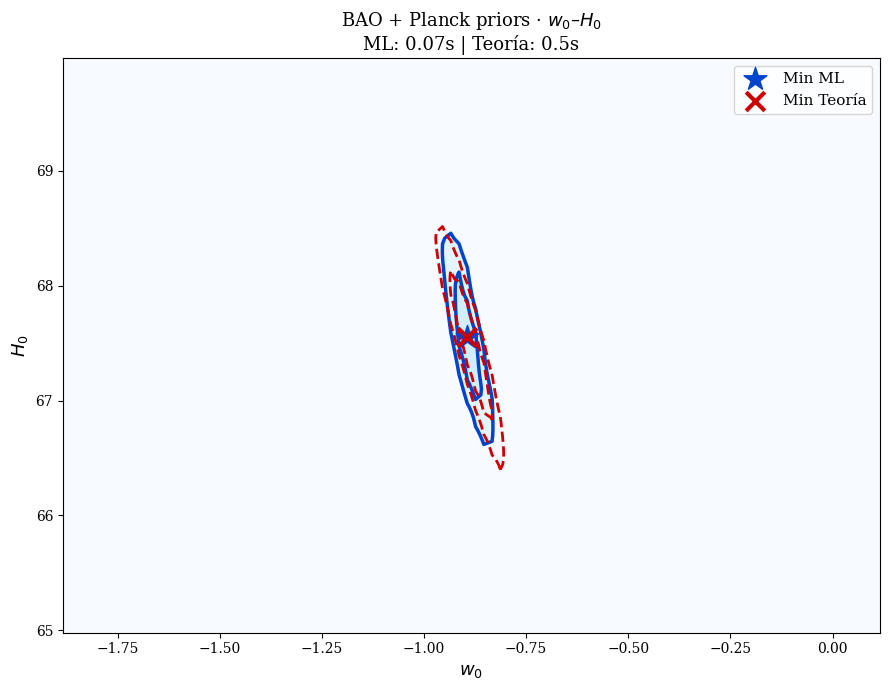

--- $H_0$ vs $w_a$  ({'Om': 0.3131189944418702, 'w0': -0.8837552582302637, 'rd': 147.1026385992456}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_wa_H0.png


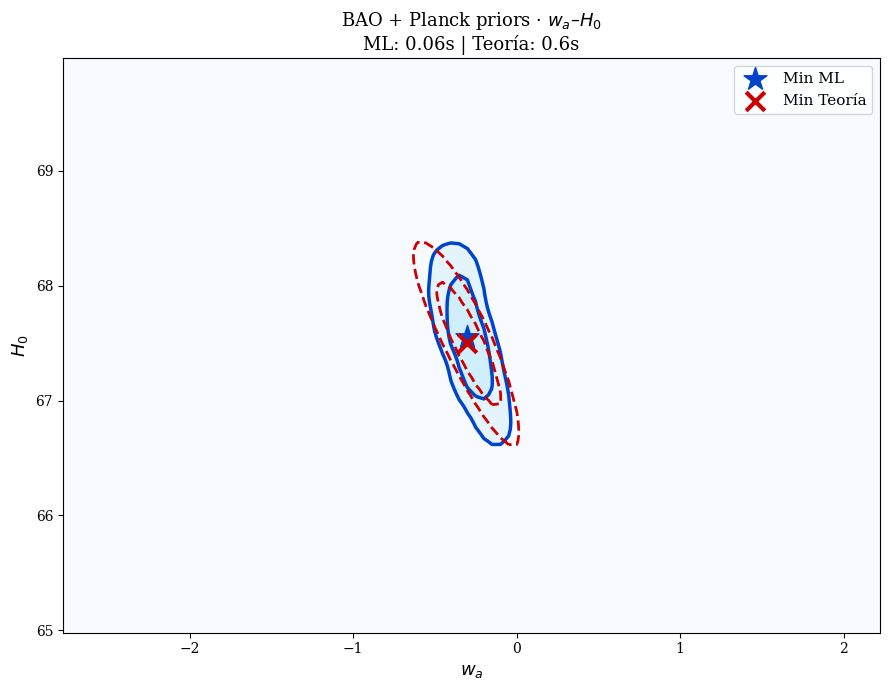

In [54]:
common = dict(res=100, sigma=2.0, theory_threshold=20)
RANGES = dict(
    Om=(REF['Om'] - 0.03, REF['Om'] + 0.03),
    w0=(REF['w0'] - 1.0,  REF['w0'] + 1.0),
    wa=(REF['wa'] - 2.5,  REF['wa'] + 2.5),
    H0=(REF['H0'] - 2.5,  REF['H0'] + 2.5),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$", H0=r"$H_0$", rd=r"$r_d$")

for x, y in [('Om','w0'), ('Om','wa'), ('Om','H0'),
             ('w0','wa'), ('w0','H0'), ('wa','H0')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"BAO + Planck priors · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
    )

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_beeswarm.png


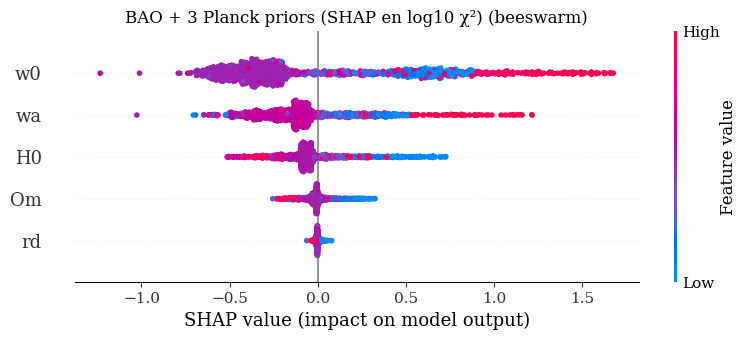

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_bar.png


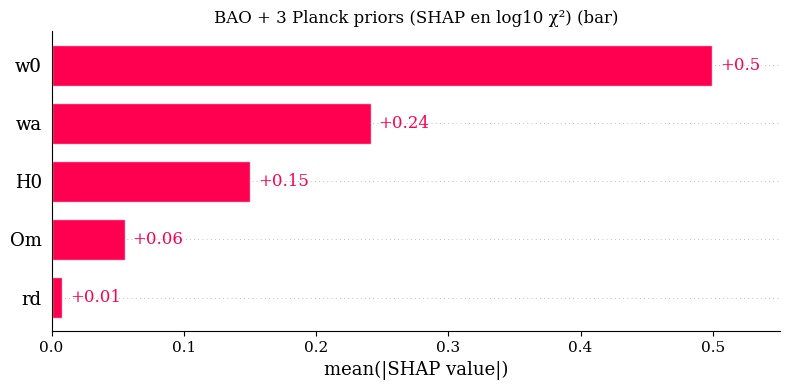

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_waterfall.png


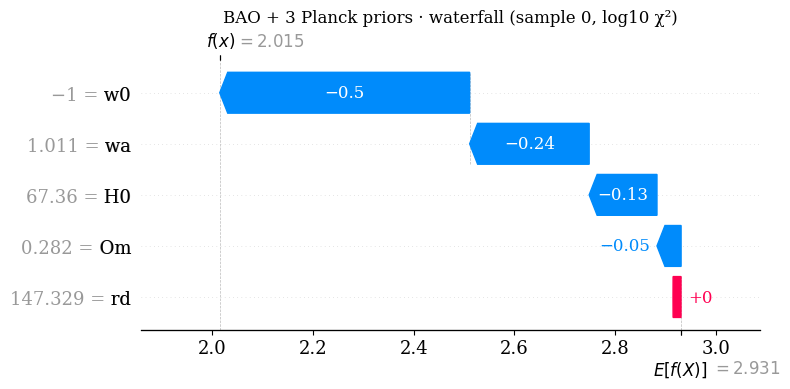

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_Om.png


<Figure size 640x480 with 0 Axes>

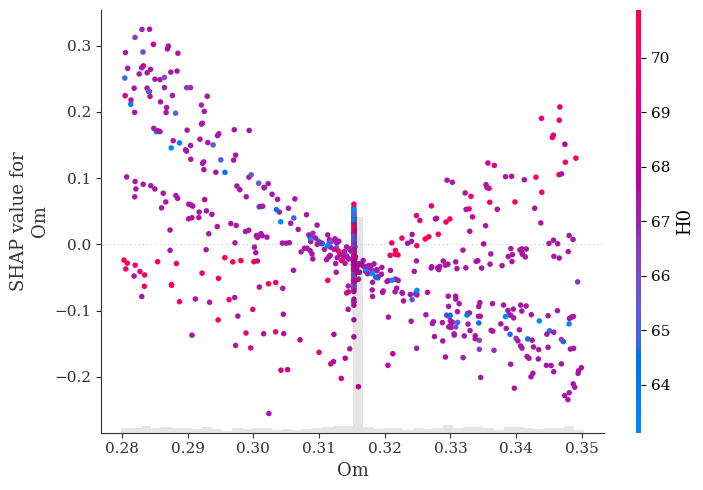

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_w0.png


<Figure size 640x480 with 0 Axes>

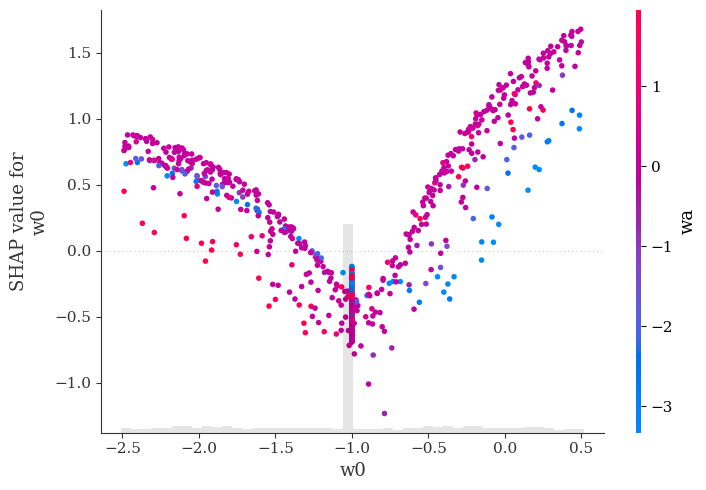

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_wa.png


<Figure size 640x480 with 0 Axes>

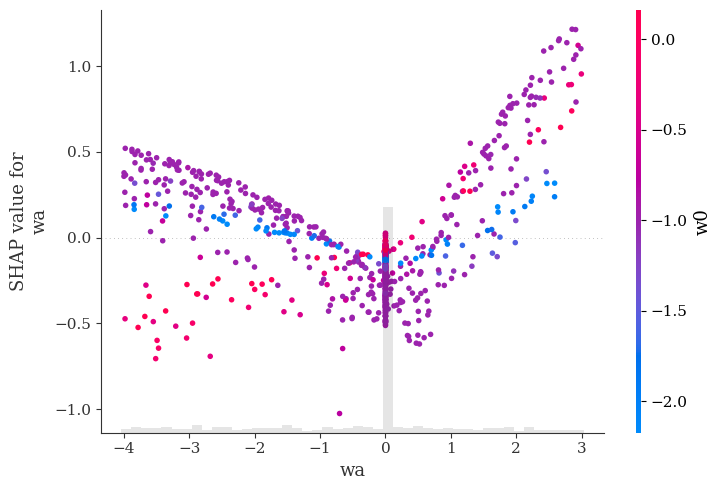

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_H0.png


<Figure size 640x480 with 0 Axes>

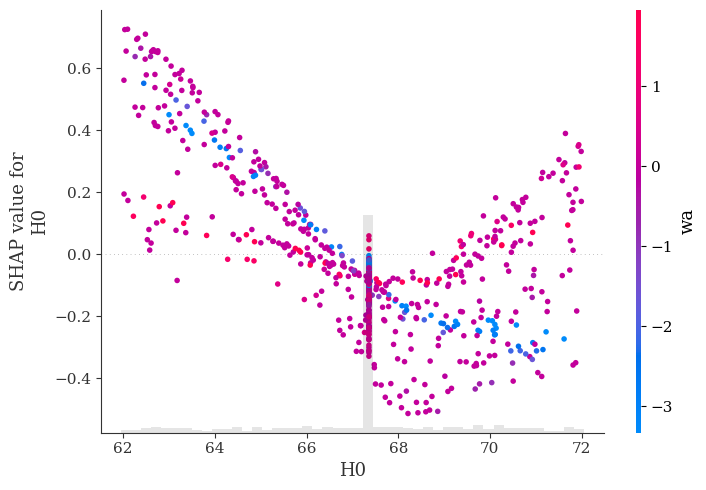

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_rd.png


<Figure size 640x480 with 0 Axes>

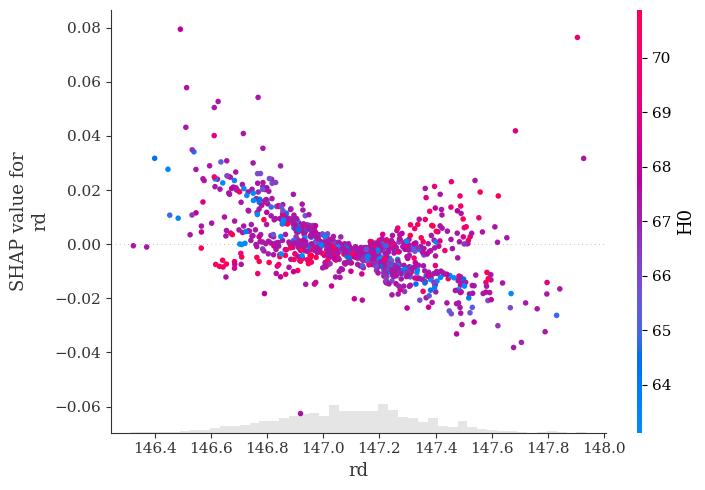

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_rd.png')]

In [47]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="BAO + 3 Planck priors (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="BAO + 3 Planck priors · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-9"></a>3.9 w₀wₐCDM + 5 Planck priors (TODOS) — 5D

**Modelo:** mismo 5D que 3.8.
**Datos:** DESI BAO DR2 + 5 priors gaussianos: Planck en Ω_m, H₀, r_d **+** Planck+SNe+BAO 2018 en w₀, wₐ (eqs. 79a/79b: w₀=-0.961±0.077, wₐ=-0.28±0.29).
**Por qué:** el ESCENARIO MÁS RESTRICTIVO. Con priors en TODOS los parámetros, los contornos se estrechan al mínimo. Útil para ver hasta dónde se puede estirar el conjunto de datos cuando se combina con todo lo conocido.

Re-anclamos `REF` al best-fit numérico del χ² 5D (los priors mueven el centro fuera de los valores Planck "puros"). Refactor de `legacy/BAO_PlankPriors/BAO_allPriors_*`.

In [101]:
SECTION = "3_9"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0", "rd"]

W0_PRIOR = (-0.961, 0.077)
WA_PRIOR = (-0.28, 0.29)

REF = dict(Om=PLANCK_OM, w0=W0_PRIOR[0], wa=WA_PRIOR[0], H0=PLANCK_H0, rd=PLANCK_RD)

def chi2_fn(Om, w0, wa, H0, rd):
    return (chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0, rd=rd)
            + planck_prior_chi2(Om=Om, H0=H0, rd=rd)
            + gaussian_prior(w0, *W0_PRIOR)
            + gaussian_prior(wa, *WA_PRIOR))

print(f"χ²(REF) = {chi2_fn(**REF):.3f}")

χ²(REF) = 38.757


In [102]:
from scipy.optimize import minimize

def builder():
    print("  optimizando χ² 5D...")
    x0 = [REF[k] for k in FEATURES]
    bounds = [(0.2, 0.4), (-1.5, -0.5), (-1.5, 1.0), (60, 75), (140, 155)]
    res = minimize(lambda x: chi2_fn(**dict(zip(FEATURES, x))),
                   x0=x0, bounds=bounds, method='Nelder-Mead')
    bf = dict(zip(FEATURES, res.x))
    print(f"  best-fit numérico: {bf}, χ²={res.fun:.3f}")

    sigmas = dict(Om=0.0073, w0=0.077, wa=0.29, H0=0.54, rd=0.26)
    rng = np.random.default_rng(42)
    samples = {k: rng.normal(bf[k], 2*sigmas[k], 40_000) for k in FEATURES}
    df_random = pd.DataFrame(samples)
    df_random['chi2'] = [chi2_fn(**df_random.iloc[i].to_dict()) for i in range(len(df_random))]

    sl_w0wa = pd.DataFrame({
        'Om': bf['Om'], 'H0': bf['H0'], 'rd': bf['rd'],
        'w0': rng.uniform(-1.3, -0.6, 8000),
        'wa': rng.uniform(-1.5, 1.0, 8000),
    })
    sl_omw0 = pd.DataFrame({
        'H0': bf['H0'], 'rd': bf['rd'], 'wa': bf['wa'],
        'Om': rng.uniform(0.28, 0.35, 8000),
        'w0': rng.uniform(-1.3, -0.6, 8000),
    })
    for sl in (sl_w0wa, sl_omw0):
        sl['chi2'] = [chi2_fn(**sl.iloc[i].to_dict()) for i in range(len(sl))]

    df_full = pd.concat([df_random, sl_w0wa, sl_omw0], ignore_index=True)[FEATURES + ['chi2']]
    df_full.to_csv(DATASET_CSV, index=False)
    print(f"  guardado: {DATASET_CSV}  ({len(df_full)} filas)")
    return df_full

df = load_or_build(DATASET_CSV, builder, force=True)
print(f"min χ² = {df['chi2'].min():.3f}")

bf_row = df.loc[df['chi2'].idxmin()]
REF = {k: float(bf_row[k]) for k in FEATURES}
print('Best-fit del dataset:')
for k, v in REF.items():
    print(f'  {k:5s} = {v:.4f}')

Generando dataset (no existe /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_9_dataset.csv)...
  optimizando χ² 5D...
  best-fit numérico: {'Om': np.float64(0.3131189944418702), 'w0': np.float64(-0.8823120146452361), 'wa': np.float64(-0.2903684797696193), 'H0': np.float64(67.47900511267325), 'rd': np.float64(147.1026385992456)}, χ²=10.128
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_9_dataset.csv  (56000 filas)
min χ² = 10.135
Best-fit del dataset:
  Om    = 0.3131
  w0    = -0.8842
  wa    = -0.2778
  H0    = 67.4790
  rd    = 147.1026


In [103]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=True,
)

  target en Shifted-Log10: rango [0.000, 4.095]


  entrenamiento: 18.47s | R²=0.98401 | best_iter=987/3000  (early stop, ahorro ~67%)
  modelo cacheado: 3_9_model.ubj


  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_learning_curve.png


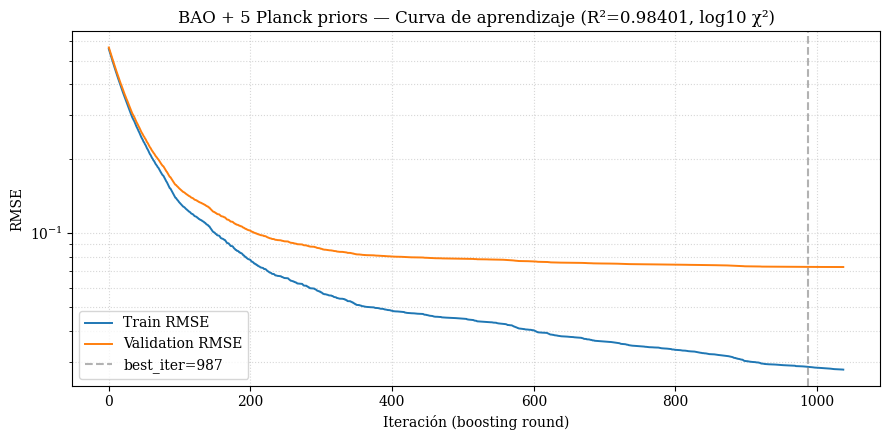

In [104]:
plot_learning_curve(
    info,
    title=f"BAO + 5 Planck priors — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w_0$ vs $\Omega_m$  ({'wa': -0.27782816159692514, 'H0': 67.47900511267325, 'rd': 147.1026385992456}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_Om_w0.png


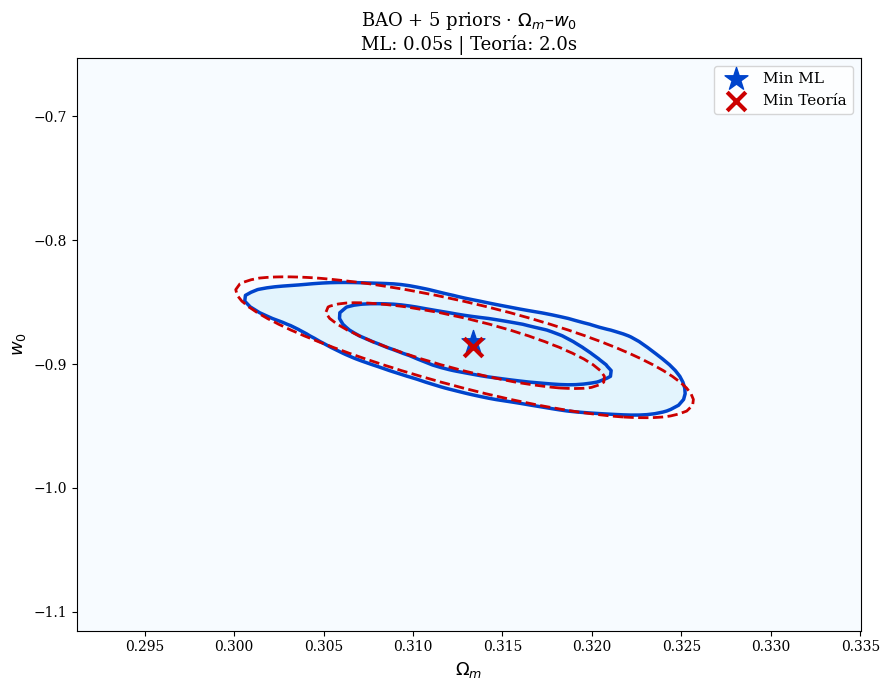

--- $w_a$ vs $w_0$  ({'Om': 0.3131189944418702, 'H0': 67.47900511267325, 'rd': 147.1026385992456}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_w0_wa.png


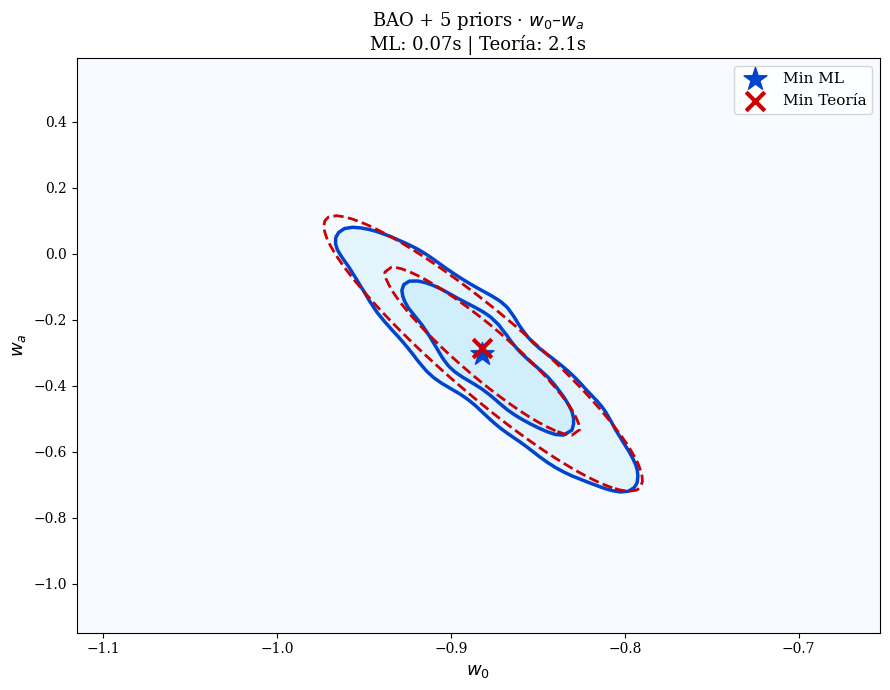

--- $w_0$ vs $H_0$  ({'Om': 0.3131189944418702, 'wa': -0.27782816159692514, 'rd': 147.1026385992456}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_H0_w0.png


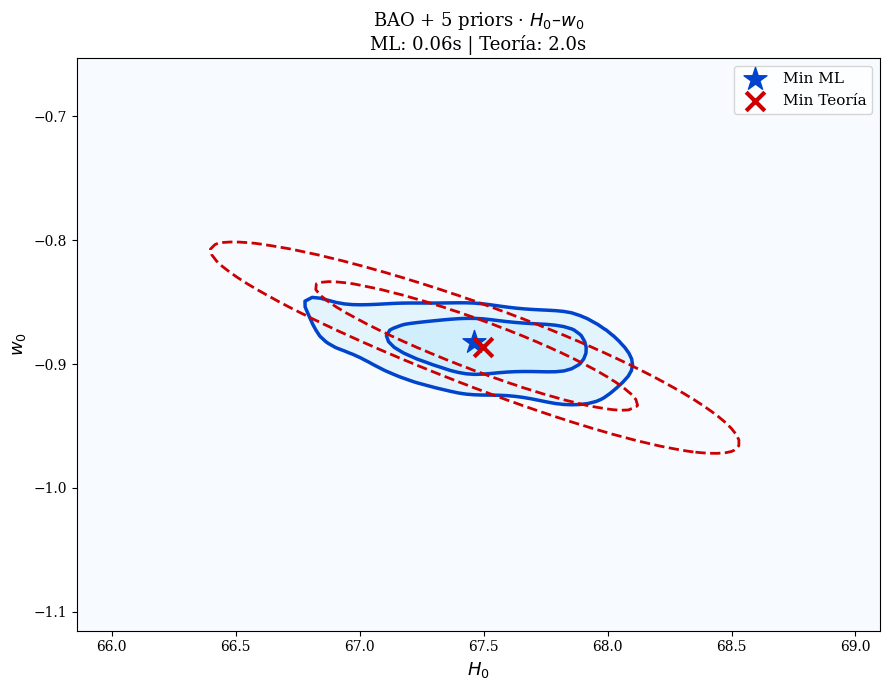

--- $H_0$ vs $\Omega_m$  ({'w0': -0.8842212999049102, 'wa': -0.27782816159692514, 'rd': 147.1026385992456}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_Om_H0.png


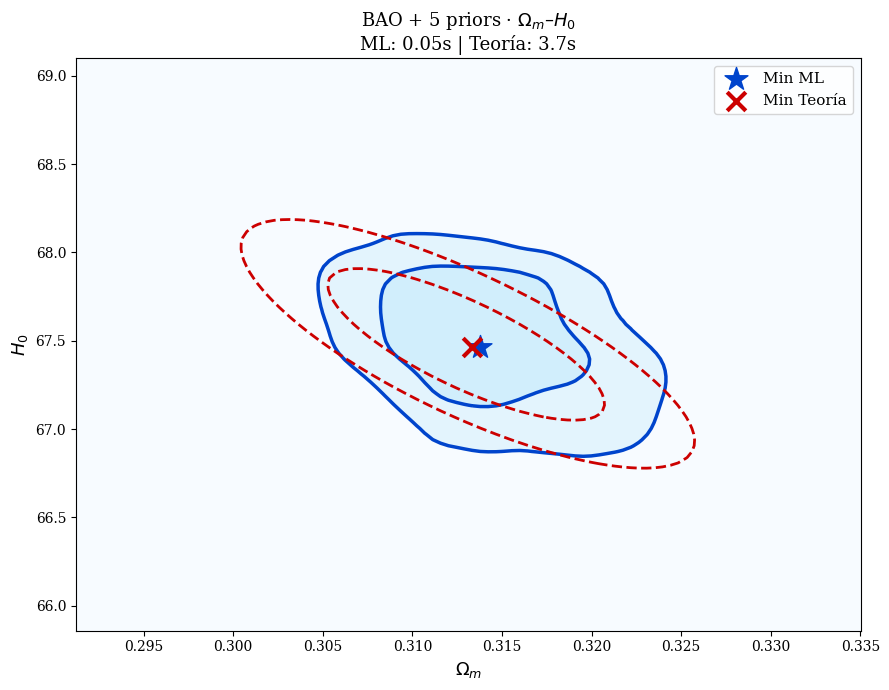

--- $H_0$ vs $r_d$  ({'Om': 0.3131189944418702, 'w0': -0.8842212999049102, 'wa': -0.27782816159692514}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_rd_H0.png


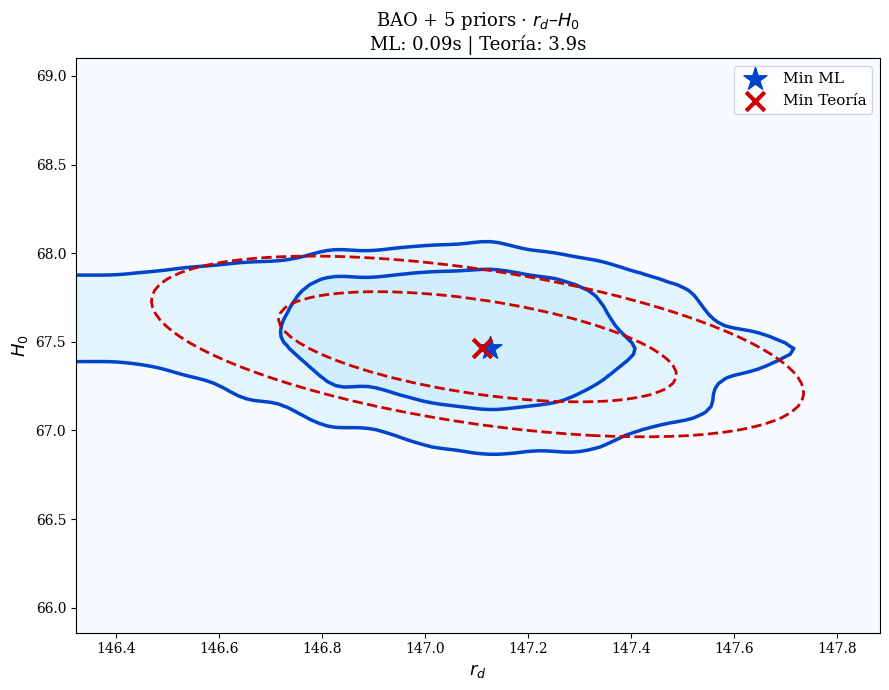

In [105]:
common = dict(res=100, sigma=2.0, theory_threshold=30)
SIGMAS = dict(Om=0.0073, w0=0.077, wa=0.29, H0=0.54, rd=0.26)
RANGES = {k: (REF[k] - 3*SIGMAS[k], REF[k] + 3*SIGMAS[k]) for k in FEATURES}
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$", H0=r"$H_0$", rd=r"$r_d$")

for x, y in [('Om','w0'), ('w0','wa'), ('H0','w0'), ('Om','H0'), ('rd','H0')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"BAO + 5 priors · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
    )

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_beeswarm.png


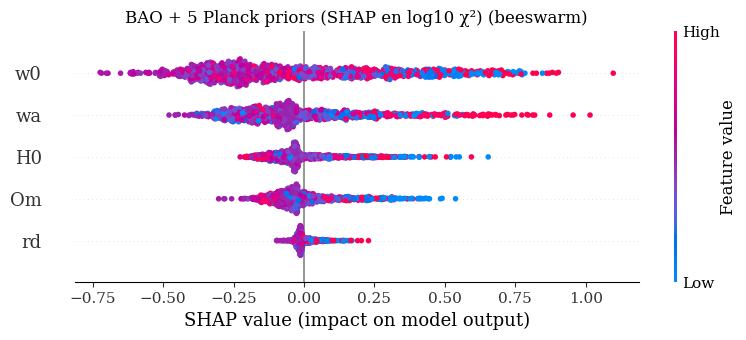

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_bar.png


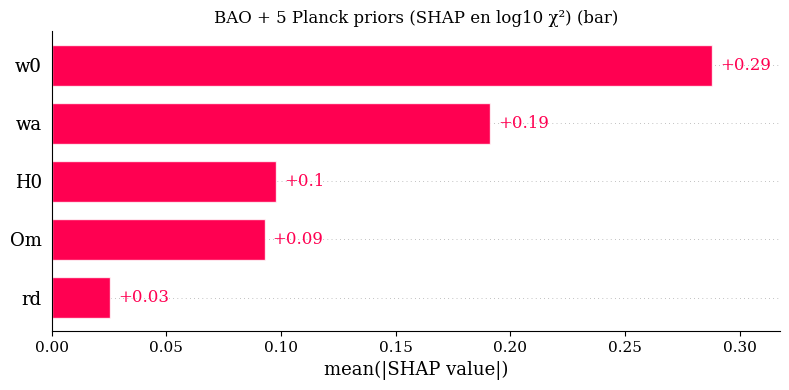

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_waterfall.png


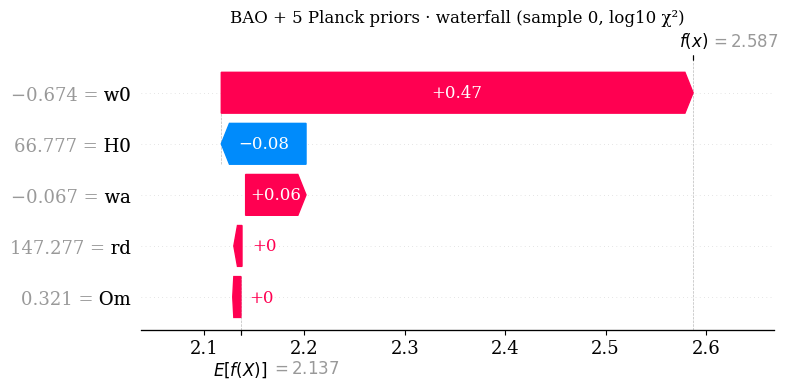

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_Om.png


<Figure size 640x480 with 0 Axes>

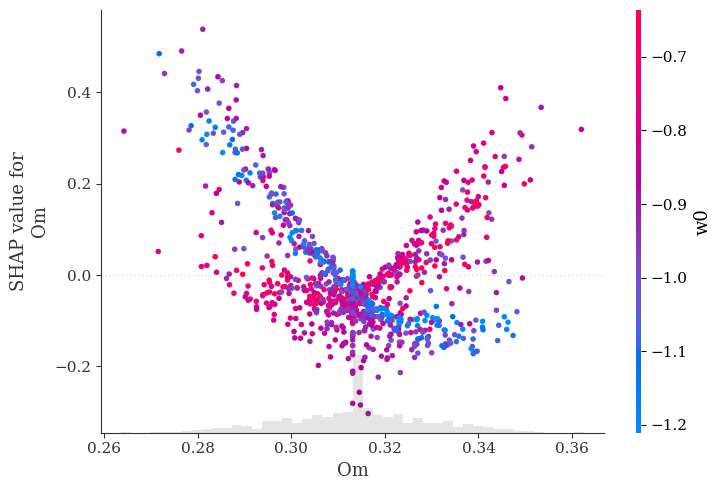

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_w0.png


<Figure size 640x480 with 0 Axes>

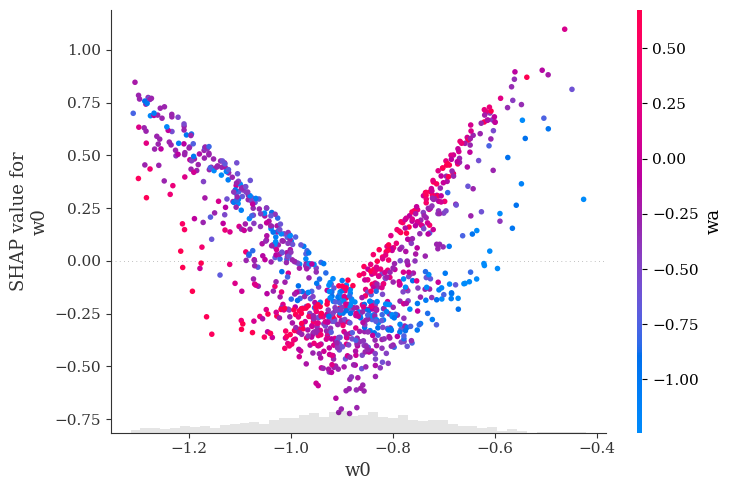

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_wa.png


<Figure size 640x480 with 0 Axes>

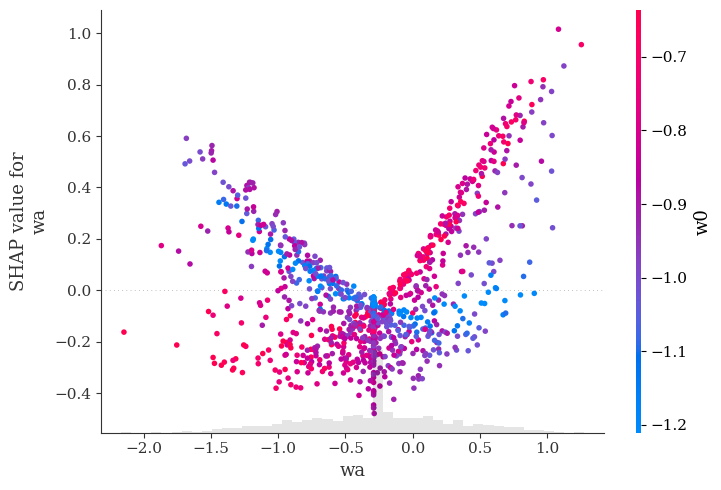

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_H0.png


<Figure size 640x480 with 0 Axes>

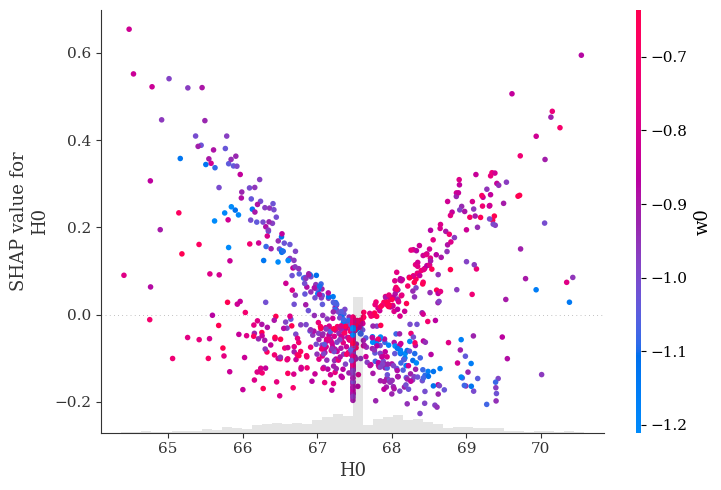

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_rd.png


<Figure size 640x480 with 0 Axes>

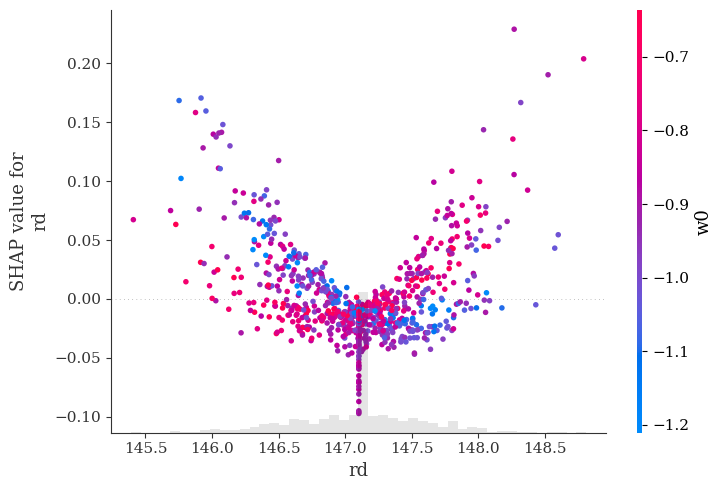

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_rd.png')]

In [53]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="BAO + 5 Planck priors (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="BAO + 5 Planck priors · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)